# ECG Analysis Pipeline — MIT-BIH Arrhythmia Database
## Heart Rate + AFib Detection + Stress Analysis + Groq LLM Report

**Dataset:** MIT-BIH Arrhythmia Database (PhysioNet)

**Pipeline:**
1. Install dependencies
2. Download MIT-BIH dataset
3. Load & visualize raw ECG
4. Preprocess signal
5. R-peak detection (Pan-Tompkins)
6. Heart Rate calculation
7. AFib detection
8. Stress detection (HRV)
9. Groq LLM health report
10. Full dashboard


## CELL 1 — Install All Dependencies

In [11]:
# Install all required packages
!pip install wfdb numpy scipy matplotlib seaborn pandas groq neurokit2 plotly -q

print('All packages installed successfully!')

All packages installed successfully!


## CELL 2 — Import All Libraries

In [12]:
import wfdb                          # Read MIT-BIH .dat/.hea/.atr files
import numpy as np                   # Numerical operations
import pandas as pd                  # Data manipulation
import matplotlib.pyplot as plt      # Plotting
import matplotlib.gridspec as gridspec
import seaborn as sns                # Beautiful plots
import plotly.graph_objects as go    # Interactive plots
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.signal import butter, filtfilt, iirnotch, find_peaks, welch
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('dark_background')
sns.set_palette('husl')

print(' All libraries imported!')
print(' WFDB version:', wfdb.__version__)

 All libraries imported!
 WFDB version: 4.3.1


## CELL 3 — Download MIT-BIH Dataset from PhysioNet

In [13]:
import wfdb
import os

# MIT-BIH record list (48 records total, we use key ones)
RECORDS = ['100', '101', '102', '103', '104', '105',
           '106', '107', '108', '109', '111', '112',
           '113', '114', '115', '116', '117', '118',
           '119', '121', '122', '123', '124', '200',
           '201', '202', '203', '205', '207', '208',
           '209', '210', '212', '213', '214', '215',
           '217', '219', '220', '221', '222', '223',
           '228', '230', '231', '232', '233', '234']

# Download just the first record for demo (record 100)
# Change this to download more if needed
DEMO_RECORD = '100'

print(f' Downloading MIT-BIH Record {DEMO_RECORD}...')

# This downloads .dat, .hea, .atr files automatically
wfdb.dl_database('mitdb', dl_dir='mitdb/', records=[DEMO_RECORD])

print(f' Download complete!')
print(' Files downloaded:')
for f in os.listdir('mitdb/'):
    if DEMO_RECORD in f:
        size = os.path.getsize(f'mitdb/{f}')
        print(f'   {f} — {size/1024:.1f} KB')

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
 Download complete!
 Files downloaded:
   100.atr — 4.5 KB
   100.dat — 1904.3 KB
   100.hea — 0.1 KB


## CELL 4 — Load ECG Record & Explore

In [14]:
# Load the ECG record
RECORD_PATH = 'mitdb/100'

# Read signal
record = wfdb.rdrecord(RECORD_PATH)

# Read annotations (ground truth beat labels)
annotation = wfdb.rdann(RECORD_PATH, 'atr')

# Extract data
ecg_signal = record.p_signal[:, 0]   # Lead 1 (MLII)
fs = record.fs                         # Sampling frequency (360 Hz for MIT-BIH)
n_samples = len(ecg_signal)
duration_sec = n_samples / fs
time_axis = np.arange(n_samples) / fs  # Time in seconds

# Annotation info
ann_samples = annotation.sample        # Sample indices of beats
ann_symbols = annotation.symbol        # Beat type labels

print('=' * 50)
print(f' RECORD INFORMATION')
print('=' * 50)
print(f'Patient ID         : {record.record_name}')
print(f'Sampling Rate      : {fs} Hz')
print(f'Total Samples      : {n_samples:,}')
print(f'Duration           : {duration_sec/60:.1f} minutes ({duration_sec:.0f} seconds)')
print(f'Lead Names         : {record.sig_name}')
print(f'ECG Units          : {record.units}')
print(f'Signal Range       : {ecg_signal.min():.3f} to {ecg_signal.max():.3f} mV')
print(f'Total Annotations  : {len(ann_samples)}')
print(f'Beat Types Found   : {set(ann_symbols)}')
print('=' * 50)

# Beat type legend
beat_legend = {
    'N': 'Normal beat',
    'L': 'Left bundle branch block',
    'R': 'Right bundle branch block',
    'A': 'Atrial premature beat',
    'V': 'Premature ventricular contraction',
    'F': 'Fusion beat',
    '/': 'Paced beat',
    'f': 'Fusion of paced and normal beat',
    '~': 'Signal quality change'
}

print('\n Beat Type Breakdown:')
from collections import Counter
beat_counts = Counter(ann_symbols)
for beat, count in beat_counts.most_common():
    label = beat_legend.get(beat, 'Other')
    print(f'   [{beat}] {label}: {count} beats')

 RECORD INFORMATION
Patient ID         : 100
Sampling Rate      : 360 Hz
Total Samples      : 650,000
Duration           : 30.1 minutes (1806 seconds)
Lead Names         : ['MLII', 'V5']
ECG Units          : ['mV', 'mV']
Signal Range       : -2.715 to 1.435 mV
Total Annotations  : 2274
Beat Types Found   : {'N', '+', 'A', 'V'}

 Beat Type Breakdown:
   [N] Normal beat: 2239 beats
   [A] Atrial premature beat: 33 beats
   [+] Other: 1 beats
   [V] Premature ventricular contraction: 1 beats


## CELL 5 — Visualize Raw ECG Signal

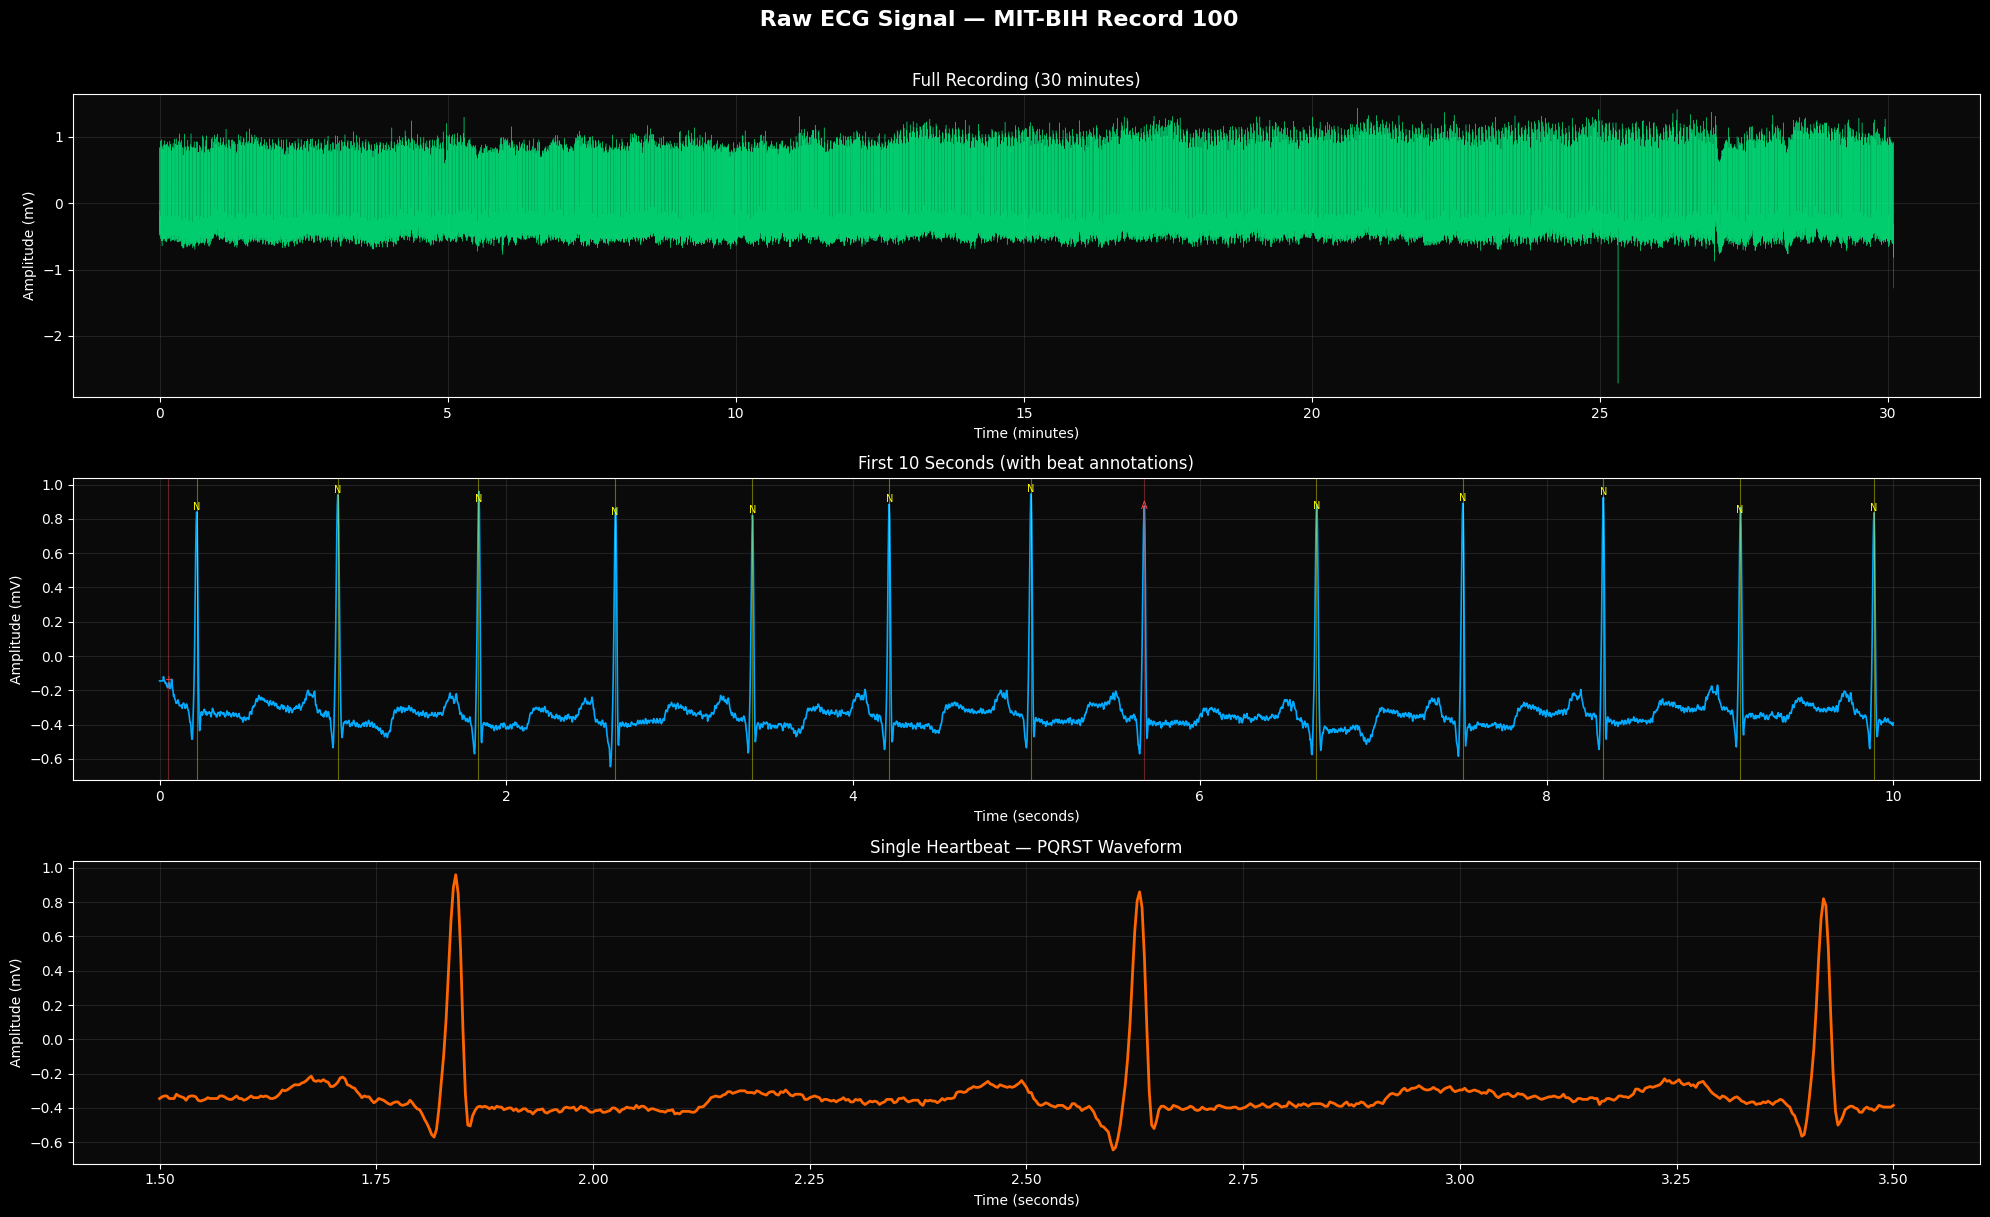

Raw ECG plots generated!


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12))
fig.suptitle(' Raw ECG Signal — MIT-BIH Record 100',
             fontsize=16, fontweight='bold', color='white', y=1.01)

# --- Plot 1: Full recording overview ---
ax1 = axes[0]
ax1.plot(time_axis/60, ecg_signal, color='#00ff88', linewidth=0.3, alpha=0.8)
ax1.set_title('Full Recording (30 minutes)', color='white', fontsize=12)
ax1.set_xlabel('Time (minutes)', color='white')
ax1.set_ylabel('Amplitude (mV)', color='white')
ax1.tick_params(colors='white')
ax1.set_facecolor('#0a0a0a')
ax1.grid(True, alpha=0.2, color='gray')

# --- Plot 2: First 10 seconds with annotations ---
ax2 = axes[1]
t_end = 10  # seconds
mask = time_axis <= t_end
ax2.plot(time_axis[mask], ecg_signal[mask],
         color='#00aaff', linewidth=1.2, label='ECG Signal')

# Plot annotation markers
ann_mask = ann_samples <= t_end * fs
ann_t = ann_samples[ann_mask] / fs
ann_v = ecg_signal[ann_samples[ann_mask]]
ann_sym = np.array(ann_symbols)[ann_mask]

for t, v, s in zip(ann_t, ann_v, ann_sym):
    color = '#ff4444' if s != 'N' else '#ffff00'
    ax2.axvline(x=t, color=color, alpha=0.4, linewidth=0.8)
    ax2.annotate(s, xy=(t, v), fontsize=7, color=color,
                ha='center', va='bottom')

ax2.set_title('First 10 Seconds (with beat annotations)', color='white', fontsize=12)
ax2.set_xlabel('Time (seconds)', color='white')
ax2.set_ylabel('Amplitude (mV)', color='white')
ax2.tick_params(colors='white')
ax2.set_facecolor('#0a0a0a')
ax2.grid(True, alpha=0.2, color='gray')

# --- Plot 3: Single heartbeat zoomed ---
ax3 = axes[2]
t_start_zoom = 1.5  # seconds
t_end_zoom = 3.5
zoom_mask = (time_axis >= t_start_zoom) & (time_axis <= t_end_zoom)
ax3.plot(time_axis[zoom_mask], ecg_signal[zoom_mask],
         color='#ff6600', linewidth=2.0)

# Label P, QRS, T waves roughly
ax3.set_title('Single Heartbeat — PQRST Waveform', color='white', fontsize=12)
ax3.set_xlabel('Time (seconds)', color='white')
ax3.set_ylabel('Amplitude (mV)', color='white')
ax3.tick_params(colors='white')
ax3.set_facecolor('#0a0a0a')
ax3.grid(True, alpha=0.2, color='gray')

plt.tight_layout()
plt.savefig('plot_01_raw_ecg.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('Raw ECG plots generated!')

## CELL 6 — Signal Preprocessing (Filtering)

🧹 Applying preprocessing pipeline...
    Bandpass filter applied (0.5–40 Hz)
    Notch filter applied (50 Hz powerline removal)
   Signal normalized


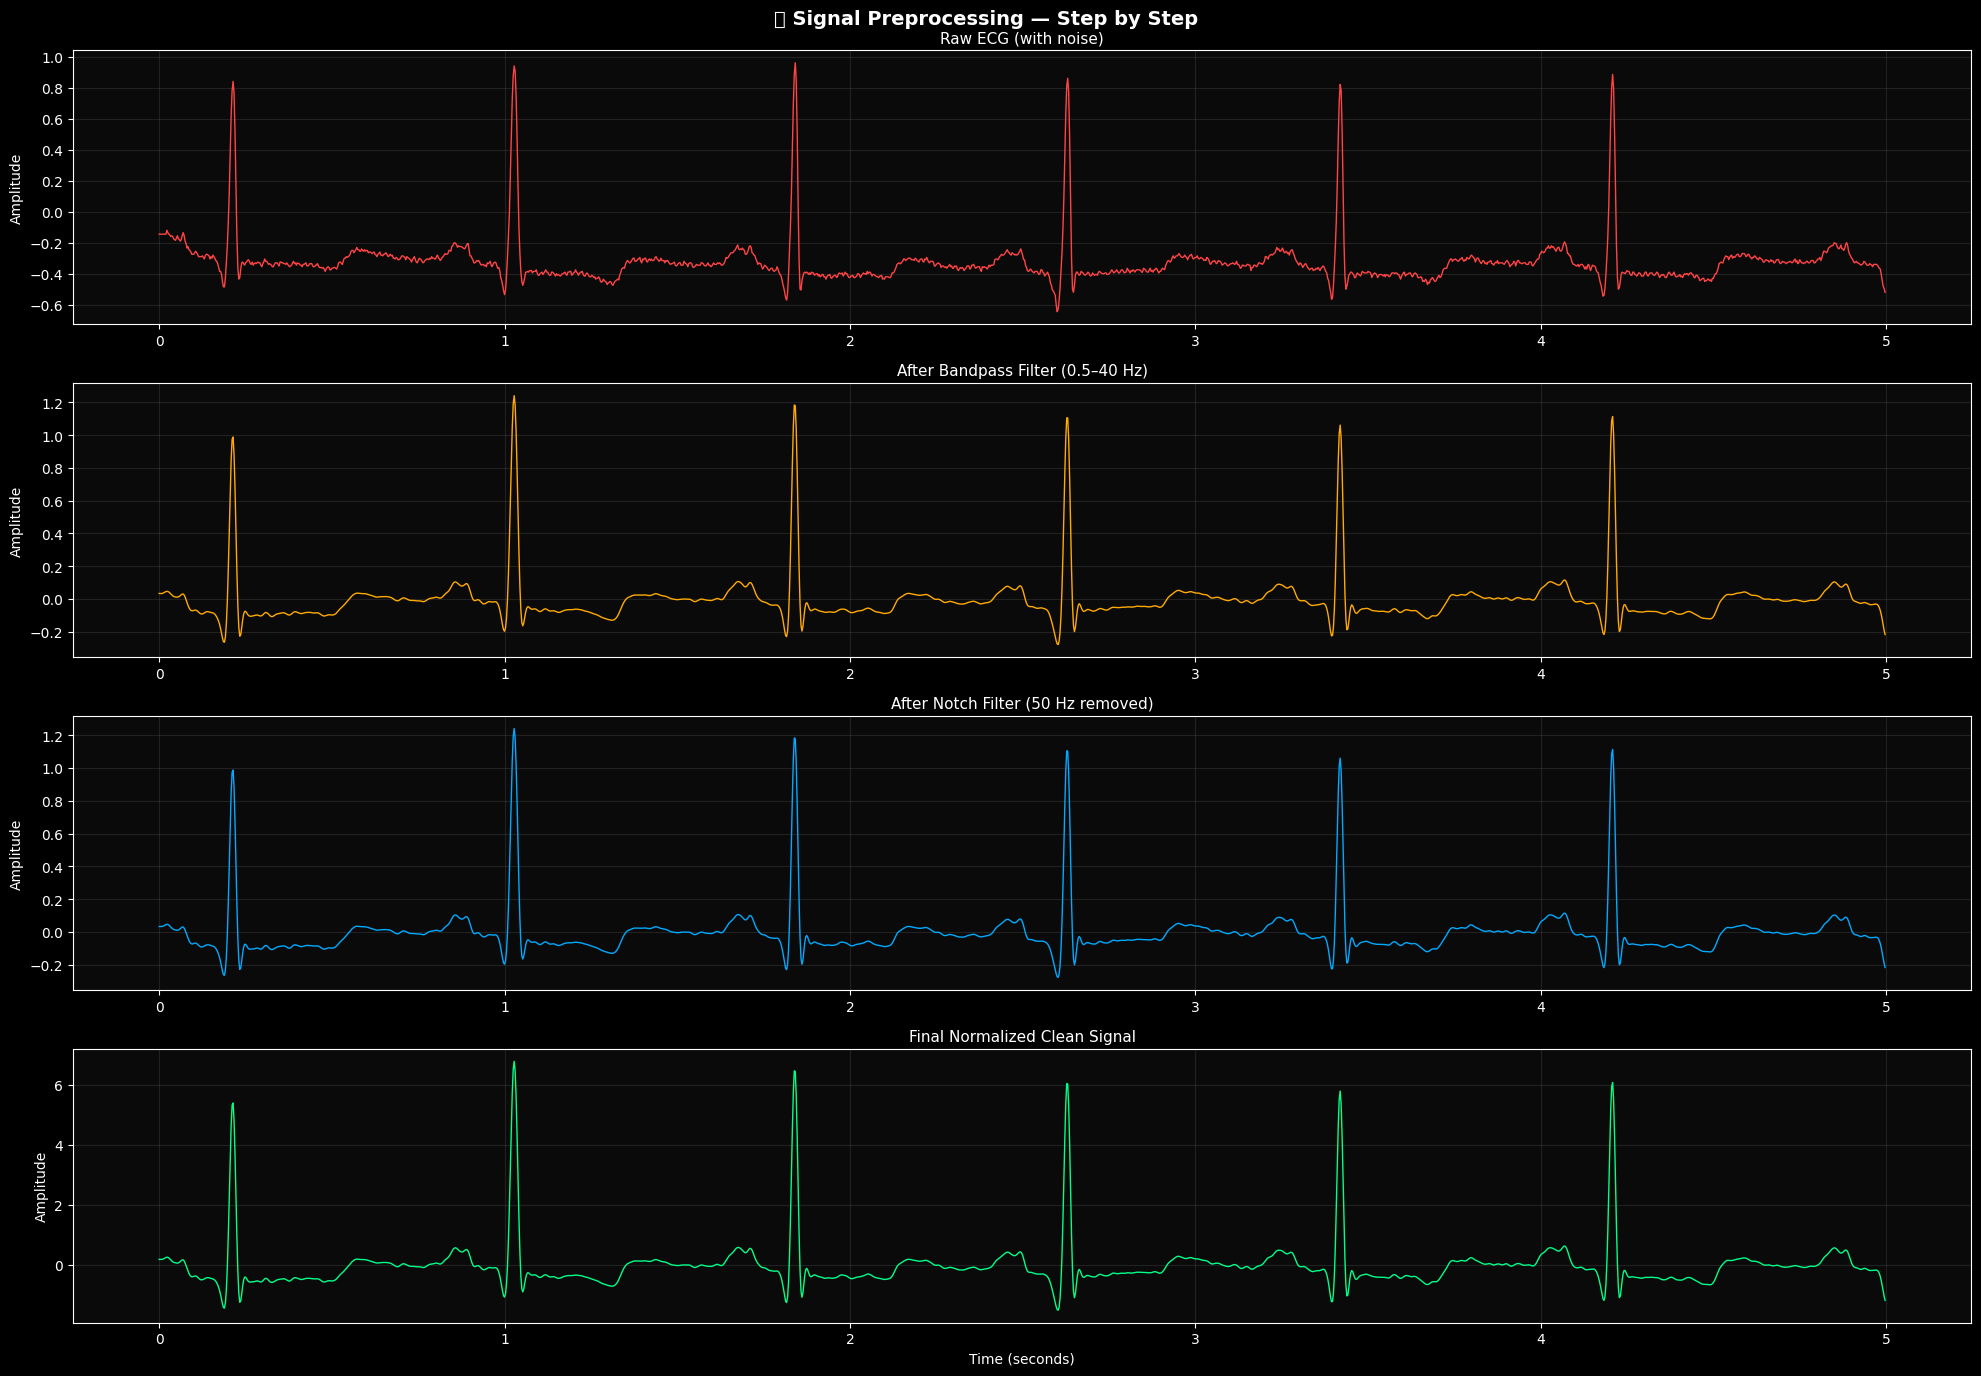

 Preprocessing complete!


In [17]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    """Remove baseline drift and high-frequency noise."""
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, freq=50.0, fs=360, Q=30):
    """Remove powerline interference (50 Hz)."""
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, signal)

def normalize_signal(signal):
    """Zero-mean unit-variance normalization."""
    return (signal - np.mean(signal)) / np.std(signal)

# Apply preprocessing pipeline
print('🧹 Applying preprocessing pipeline...')
ecg_bandpass = bandpass_filter(ecg_signal, fs=fs)
print('    Bandpass filter applied (0.5–40 Hz)')

ecg_notch = notch_filter(ecg_bandpass, freq=50, fs=fs)
print('    Notch filter applied (50 Hz powerline removal)')

ecg_clean = normalize_signal(ecg_notch)
print('   Signal normalized')

# --- Visualization: Before vs After ---
fig, axes = plt.subplots(4, 1, figsize=(20, 14))
fig.suptitle('🧹 Signal Preprocessing — Step by Step',
             fontsize=14, fontweight='bold', color='white')

t_show = time_axis[:fs*5]  # First 5 seconds
n_show = fs * 5

signals = [
    (ecg_signal[:n_show],    '#ff4444', 'Raw ECG (with noise)'),
    (ecg_bandpass[:n_show],  '#ffaa00', 'After Bandpass Filter (0.5–40 Hz)'),
    (ecg_notch[:n_show],     '#00aaff', 'After Notch Filter (50 Hz removed)'),
    (ecg_clean[:n_show],     '#00ff88', 'Final Normalized Clean Signal'),
]

for ax, (sig, color, title) in zip(axes, signals):
    ax.plot(t_show, sig, color=color, linewidth=1.0)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_ylabel('Amplitude', color='white')
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')

axes[-1].set_xlabel('Time (seconds)', color='white')
plt.tight_layout()
plt.savefig('plot_02_preprocessing.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print(' Preprocessing complete!')

## CELL 7 — Pan-Tompkins R-Peak Detection

 Running Pan-Tompkins R-Peak Detection...
   Detected R-peaks  : 117
   Ground Truth Beats: 2273
   Detection Rate    : 5.1%


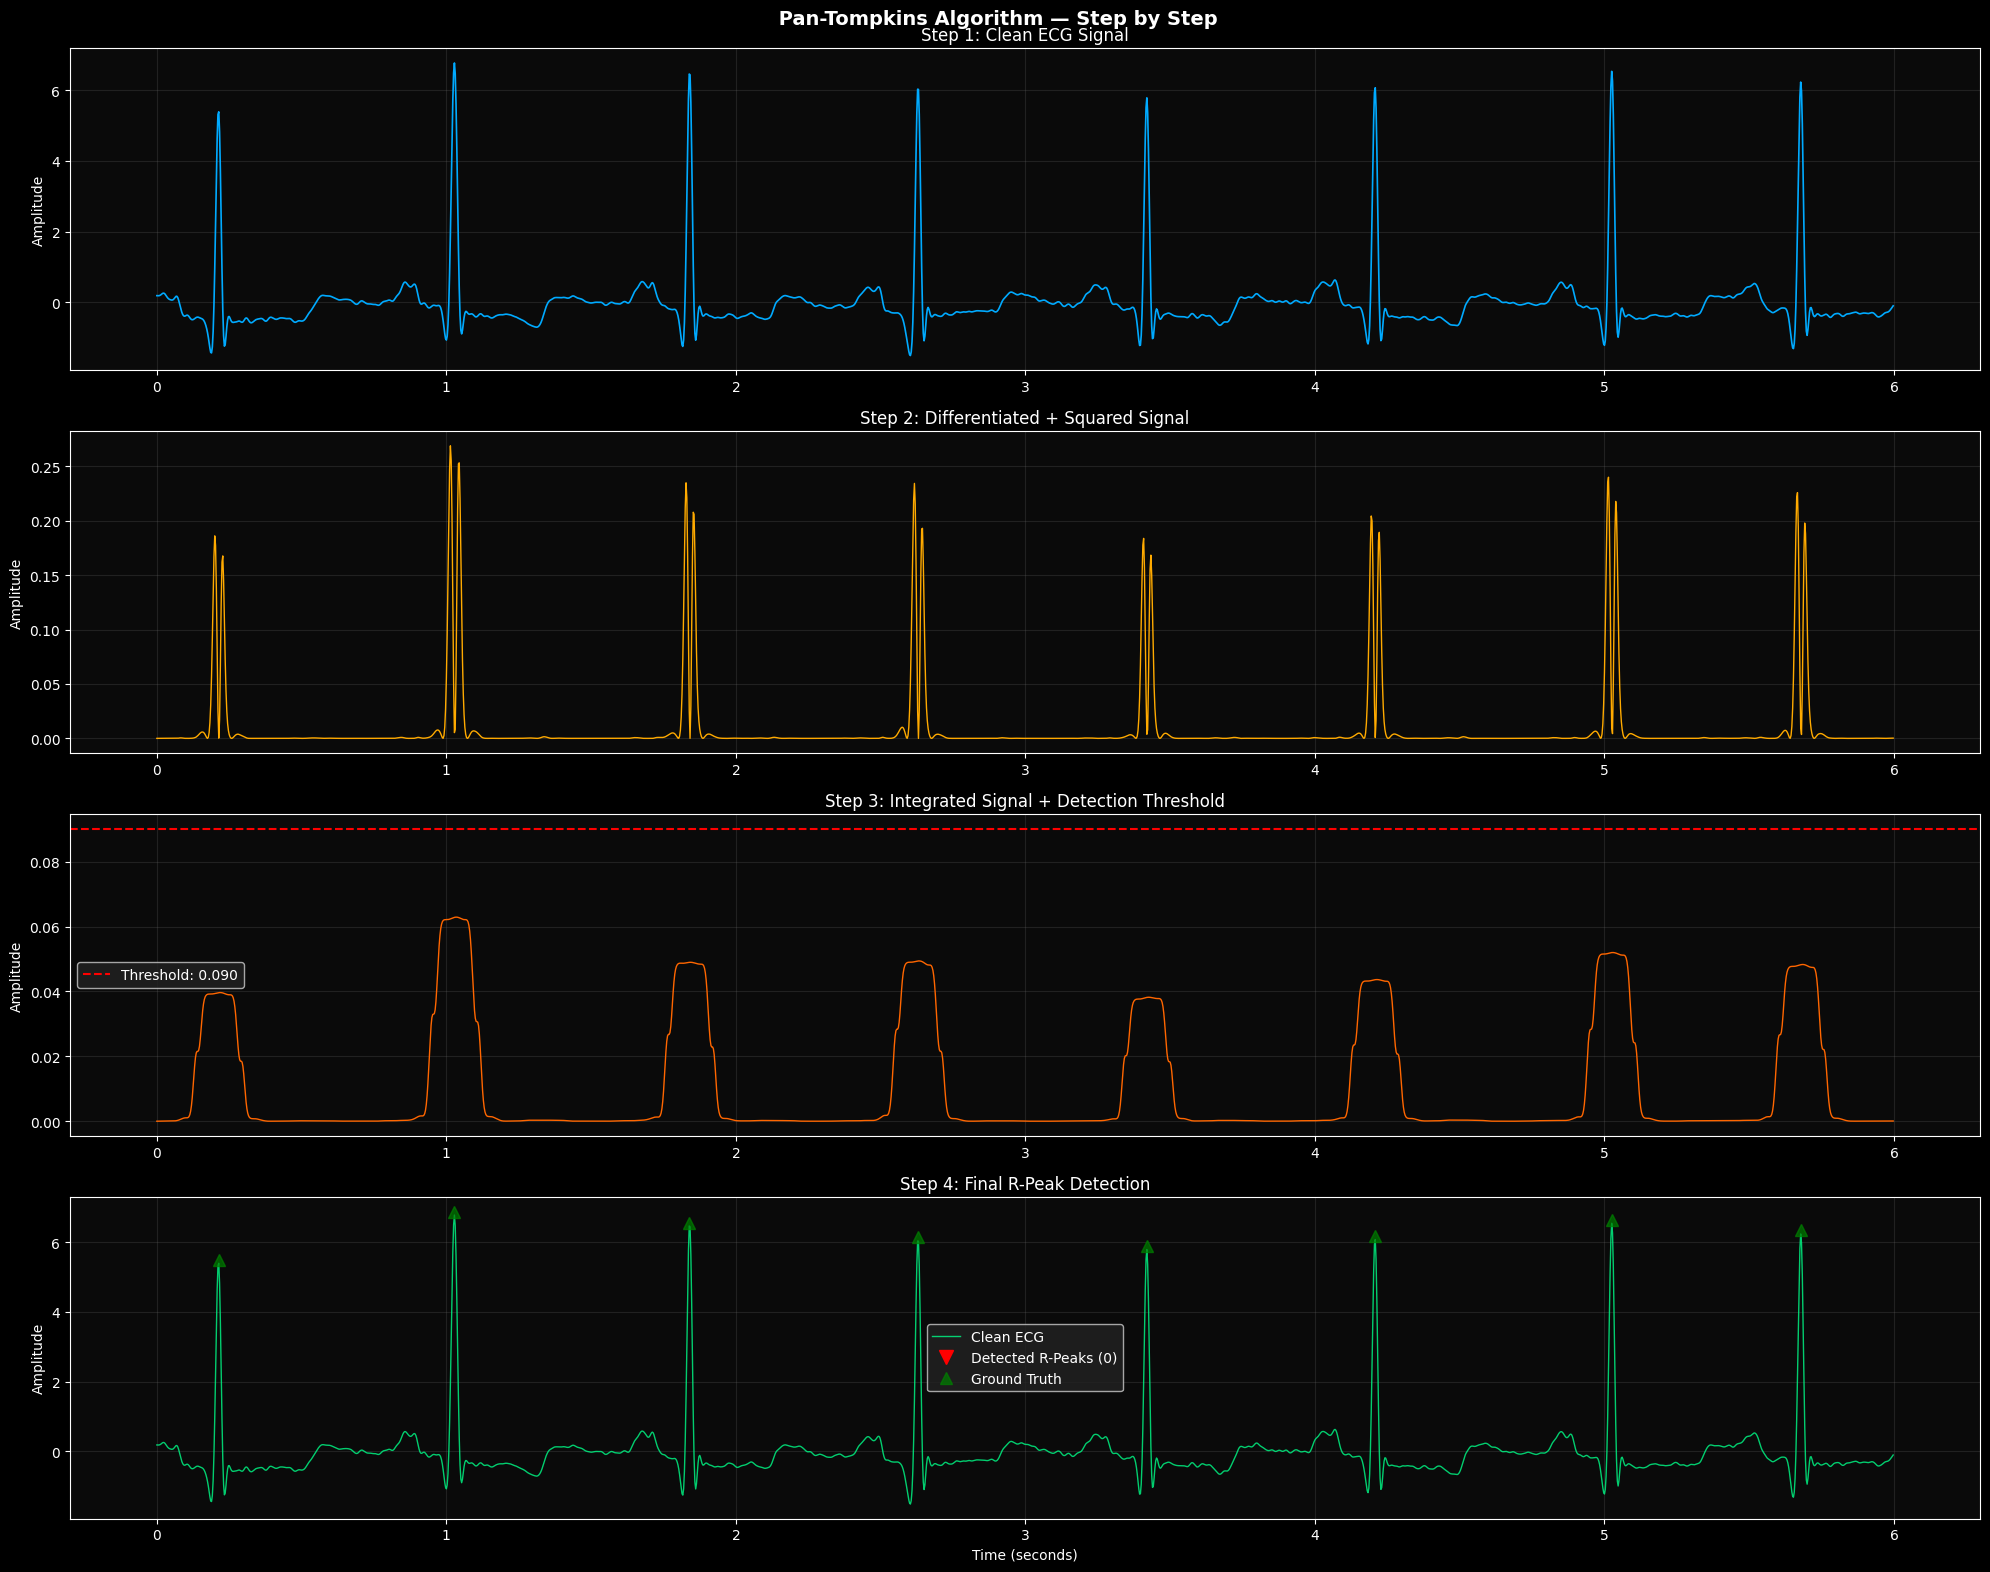

 R-peak detection complete!


In [18]:
def pan_tompkins_detector(ecg_clean, fs):
    """
    Pan-Tompkins Algorithm for R-Peak Detection.
    Steps: Bandpass → Derivative → Square → Integration → Threshold
    """
    # Step 1: Bandpass 5-15 Hz (focuses on QRS)
    nyq = fs / 2
    b, a = butter(1, [5/nyq, 15/nyq], btype='band')
    bp = filtfilt(b, a, ecg_clean)

    # Step 2: Derivative (find steep slopes)
    diff = np.diff(bp, prepend=bp[0])

    # Step 3: Square (amplify peaks)
    squared = diff ** 2

    # Step 4: Moving Window Integration (150ms)
    window_size = int(0.15 * fs)
    integrated = np.convolve(squared,
                             np.ones(window_size) / window_size,
                             mode='same')

    # Step 5: Adaptive thresholding + peak finding
    threshold = 0.35 * np.max(integrated)
    min_distance = int(0.2 * fs)  # minimum 200ms between beats

    r_peaks, properties = find_peaks(
        integrated,
        height=threshold,
        distance=min_distance
    )

    return r_peaks, integrated, squared

# Run detector
print(' Running Pan-Tompkins R-Peak Detection...')
r_peaks, integrated, squared = pan_tompkins_detector(ecg_clean, fs)

# Compare with ground truth annotations
true_peaks = ann_samples[np.isin(ann_symbols, ['N', 'L', 'R', 'A', 'V', 'F'])]

print(f'   Detected R-peaks  : {len(r_peaks)}')
print(f'   Ground Truth Beats: {len(true_peaks)}')
print(f'   Detection Rate    : {len(r_peaks)/len(true_peaks)*100:.1f}%')

# --- Visualization ---
fig, axes = plt.subplots(4, 1, figsize=(20, 16))
fig.suptitle(' Pan-Tompkins Algorithm — Step by Step',
             fontsize=14, fontweight='bold', color='white')

n_show = fs * 6  # 6 seconds
t_show = time_axis[:n_show]

# 1. Clean ECG
axes[0].plot(t_show, ecg_clean[:n_show], color='#00aaff', linewidth=1.2)
axes[0].set_title('Step 1: Clean ECG Signal', color='white')

# 2. Squared signal
axes[1].plot(t_show, squared[:n_show], color='#ffaa00', linewidth=1.0)
axes[1].set_title('Step 2: Differentiated + Squared Signal', color='white')

# 3. Integrated signal
axes[2].plot(t_show, integrated[:n_show], color='#ff6600', linewidth=1.0)
threshold_line = 0.35 * np.max(integrated)
axes[2].axhline(y=threshold_line, color='red', linestyle='--',
                linewidth=1.5, label=f'Threshold: {threshold_line:.3f}')
axes[2].set_title('Step 3: Integrated Signal + Detection Threshold', color='white')
axes[2].legend(facecolor='#222', labelcolor='white')

# 4. ECG with detected peaks
axes[3].plot(t_show, ecg_clean[:n_show], color='#00ff88', linewidth=1.0,
             label='Clean ECG', alpha=0.8)
peaks_in_range = r_peaks[r_peaks < n_show]
axes[3].plot(time_axis[peaks_in_range], ecg_clean[peaks_in_range],
             'rv', markersize=10, label=f'Detected R-Peaks ({len(peaks_in_range)})', zorder=5)
# Ground truth
gt_in_range = true_peaks[true_peaks < n_show]
axes[3].plot(time_axis[gt_in_range], ecg_clean[gt_in_range] + 0.1,
             'g^', markersize=8, label='Ground Truth', alpha=0.7, zorder=4)
axes[3].set_title('Step 4: Final R-Peak Detection', color='white')
axes[3].legend(facecolor='#222', labelcolor='white')

for ax in axes:
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')
    ax.set_ylabel('Amplitude', color='white')

axes[-1].set_xlabel('Time (seconds)', color='white')
plt.tight_layout()
plt.savefig('plot_03_pan_tompkins.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print(' R-peak detection complete!')

## CELL 8 — Heart Rate Calculation & Timeline

❤️  HEART RATE ANALYSIS
Average Heart Rate : 61.1 BPM
Minimum Heart Rate : 35.7 BPM
Maximum Heart Rate : 80.0 BPM
Std Deviation      : 17.9 BPM
Mean R-R Interval  : 1100.0 ms
Total Beats        : 117
Status             : ✅ NORMAL (60-100 BPM range)


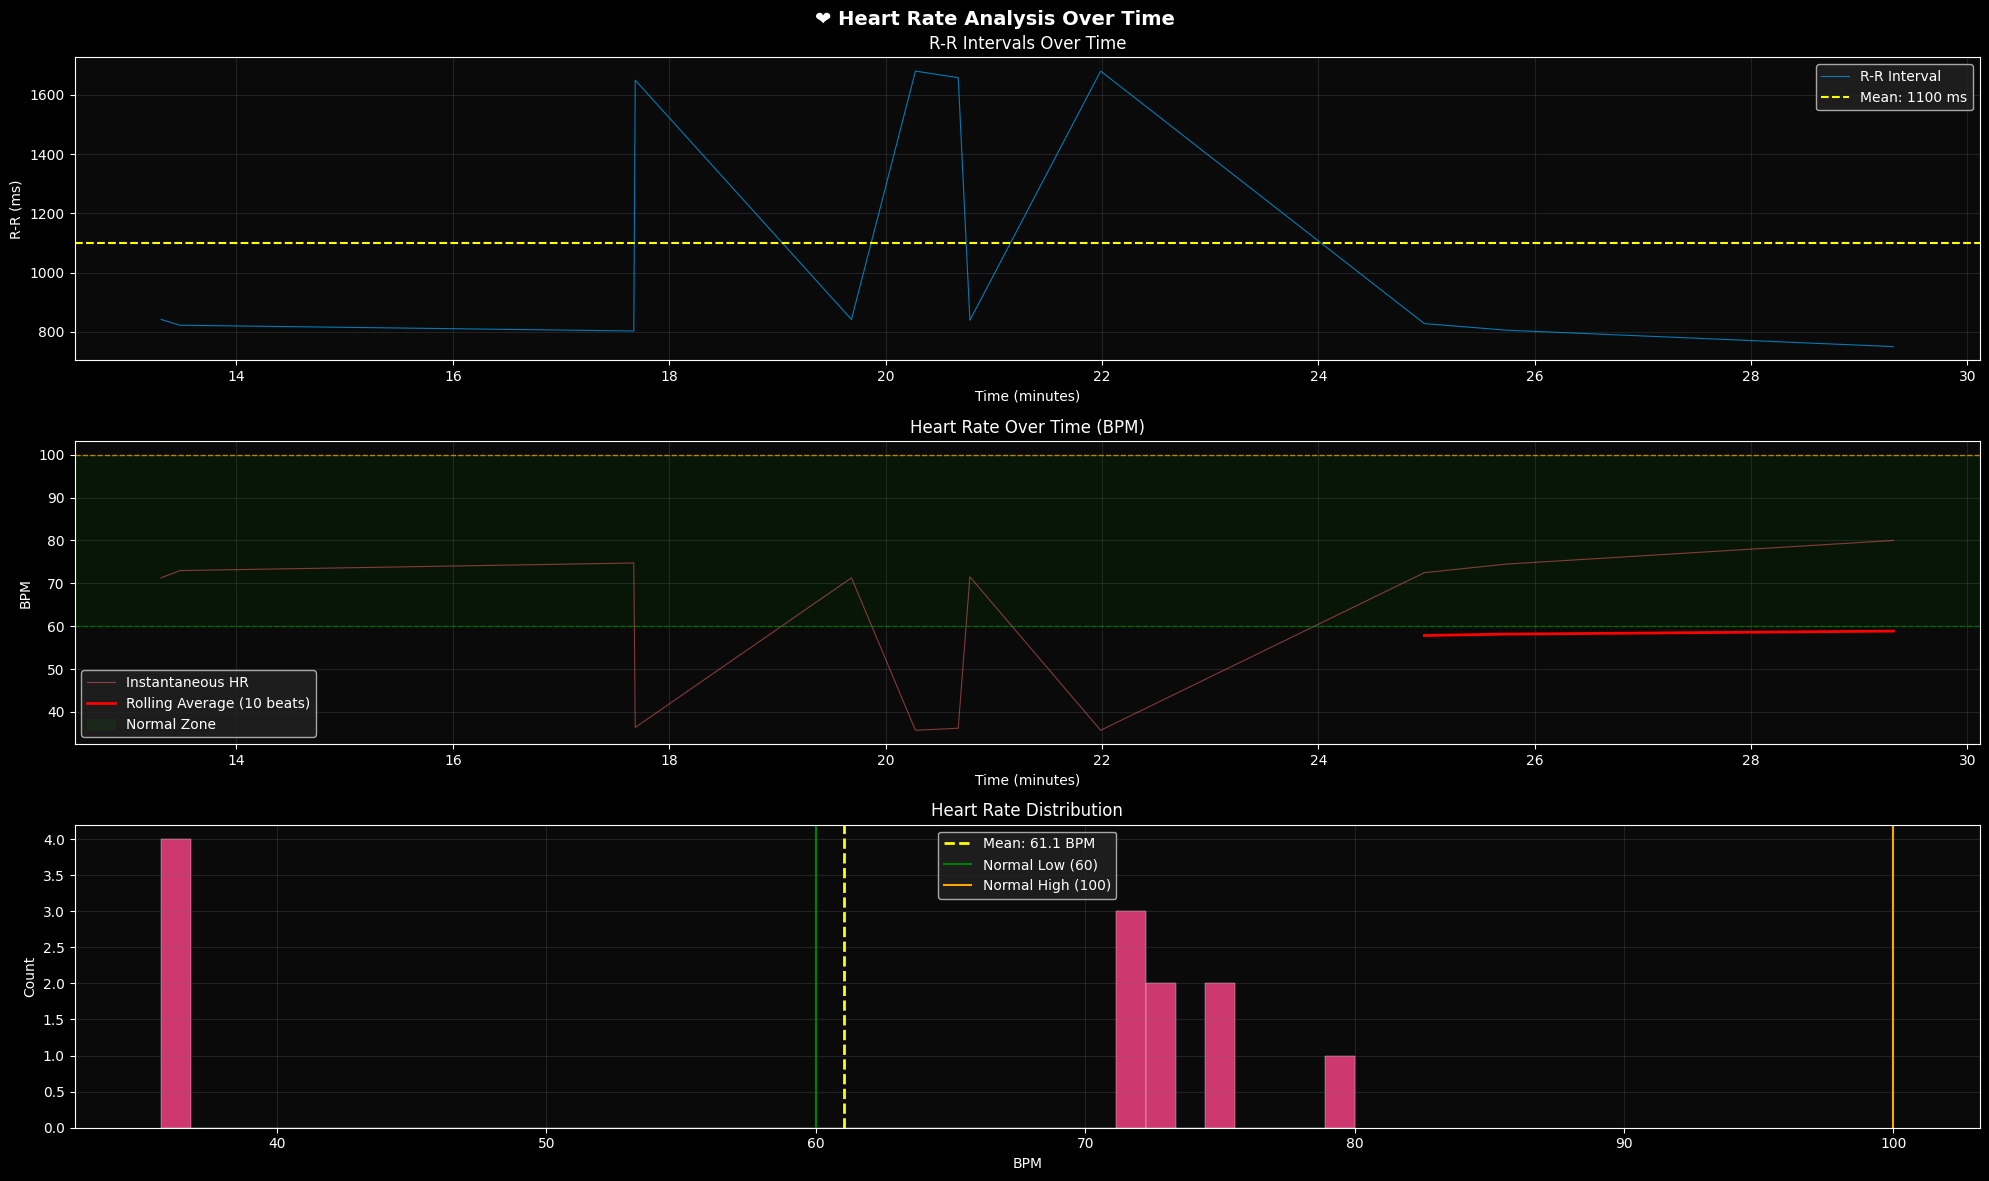

✅ Heart rate analysis complete!


In [19]:
# Calculate R-R intervals (in milliseconds)
rr_intervals_samples = np.diff(r_peaks)
rr_intervals_ms = (rr_intervals_samples / fs) * 1000  # convert to ms
rr_times = time_axis[r_peaks[:-1]]  # timestamps of R-R intervals

# Remove physiologically impossible values
valid_mask = (rr_intervals_ms > 300) & (rr_intervals_ms < 2000)  # 30-200 BPM
rr_intervals_ms = rr_intervals_ms[valid_mask]
rr_times = rr_times[valid_mask]

# Calculate heart rate
hr_bpm = 60000 / rr_intervals_ms

# Rolling average (10-beat window)
def rolling_mean(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

hr_rolling = rolling_mean(hr_bpm, w=10)
rr_rolling_t = rr_times[9:]  # adjust time axis

# Statistics
avg_hr = np.mean(hr_bpm)
min_hr = np.min(hr_bpm)
max_hr = np.max(hr_bpm)
std_hr = np.std(hr_bpm)

print('=' * 50)
print('❤️  HEART RATE ANALYSIS')
print('=' * 50)
print(f'Average Heart Rate : {avg_hr:.1f} BPM')
print(f'Minimum Heart Rate : {min_hr:.1f} BPM')
print(f'Maximum Heart Rate : {max_hr:.1f} BPM')
print(f'Std Deviation      : {std_hr:.1f} BPM')
print(f'Mean R-R Interval  : {np.mean(rr_intervals_ms):.1f} ms')
print(f'Total Beats        : {len(r_peaks)}')

if 60 <= avg_hr <= 100:
    print(f'Status             : ✅ NORMAL (60-100 BPM range)')
elif avg_hr < 60:
    print(f'Status             : ⚠️  BRADYCARDIA (< 60 BPM)')
else:
    print(f'Status             : ⚠️  TACHYCARDIA (> 100 BPM)')

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(20, 12))
fig.suptitle('❤️ Heart Rate Analysis Over Time',
             fontsize=14, fontweight='bold', color='white')

# 1. R-R intervals
axes[0].plot(rr_times/60, rr_intervals_ms,
             color='#00aaff', linewidth=0.8, alpha=0.7, label='R-R Interval')
axes[0].axhline(y=np.mean(rr_intervals_ms), color='yellow',
                linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(rr_intervals_ms):.0f} ms')
axes[0].set_title('R-R Intervals Over Time', color='white')
axes[0].set_ylabel('R-R (ms)', color='white')
axes[0].legend(facecolor='#222', labelcolor='white')

# 2. Heart rate over time
axes[1].plot(rr_times/60, hr_bpm,
             color='#ff6666', linewidth=0.8, alpha=0.5, label='Instantaneous HR')
axes[1].plot(rr_rolling_t/60, hr_rolling,
             color='#ff0000', linewidth=2.0, label='Rolling Average (10 beats)')
axes[1].axhspan(60, 100, alpha=0.1, color='green', label='Normal Zone')
axes[1].axhline(y=60, color='green', linestyle='--', linewidth=1, alpha=0.7)
axes[1].axhline(y=100, color='orange', linestyle='--', linewidth=1, alpha=0.7)
axes[1].set_title('Heart Rate Over Time (BPM)', color='white')
axes[1].set_ylabel('BPM', color='white')
axes[1].legend(facecolor='#222', labelcolor='white')

# 3. Heart rate histogram
axes[2].hist(hr_bpm, bins=40, color='#ff4488', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[2].axvline(x=avg_hr, color='yellow', linestyle='--',
                linewidth=2, label=f'Mean: {avg_hr:.1f} BPM')
axes[2].axvline(x=60, color='green', linewidth=1.5, label='Normal Low (60)')
axes[2].axvline(x=100, color='orange', linewidth=1.5, label='Normal High (100)')
axes[2].set_title('Heart Rate Distribution', color='white')
axes[2].set_xlabel('BPM', color='white')
axes[2].set_ylabel('Count', color='white')
axes[2].legend(facecolor='#222', labelcolor='white')

for ax in axes:
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')

axes[0].set_xlabel('Time (minutes)', color='white')
axes[1].set_xlabel('Time (minutes)', color='white')
plt.tight_layout()
plt.savefig('plot_04_heart_rate.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('✅ Heart rate analysis complete!')

## CELL 9 — HRV Feature Extraction

HRV FEATURES
Mean R-R       : 1100.0 ms
SDNN           : 401.95 ms  (>50 ms = healthy)
RMSSD          : 616.95 ms  (>20 ms = good vagal tone)
pNN50          : 63.64 %
CV             : 36.54 %
LF Power       : 0.0000 ms²
HF Power       : 123981.1433 ms²
LF/HF Ratio    : 0.00  (>2 = stress, <1 = relaxed)


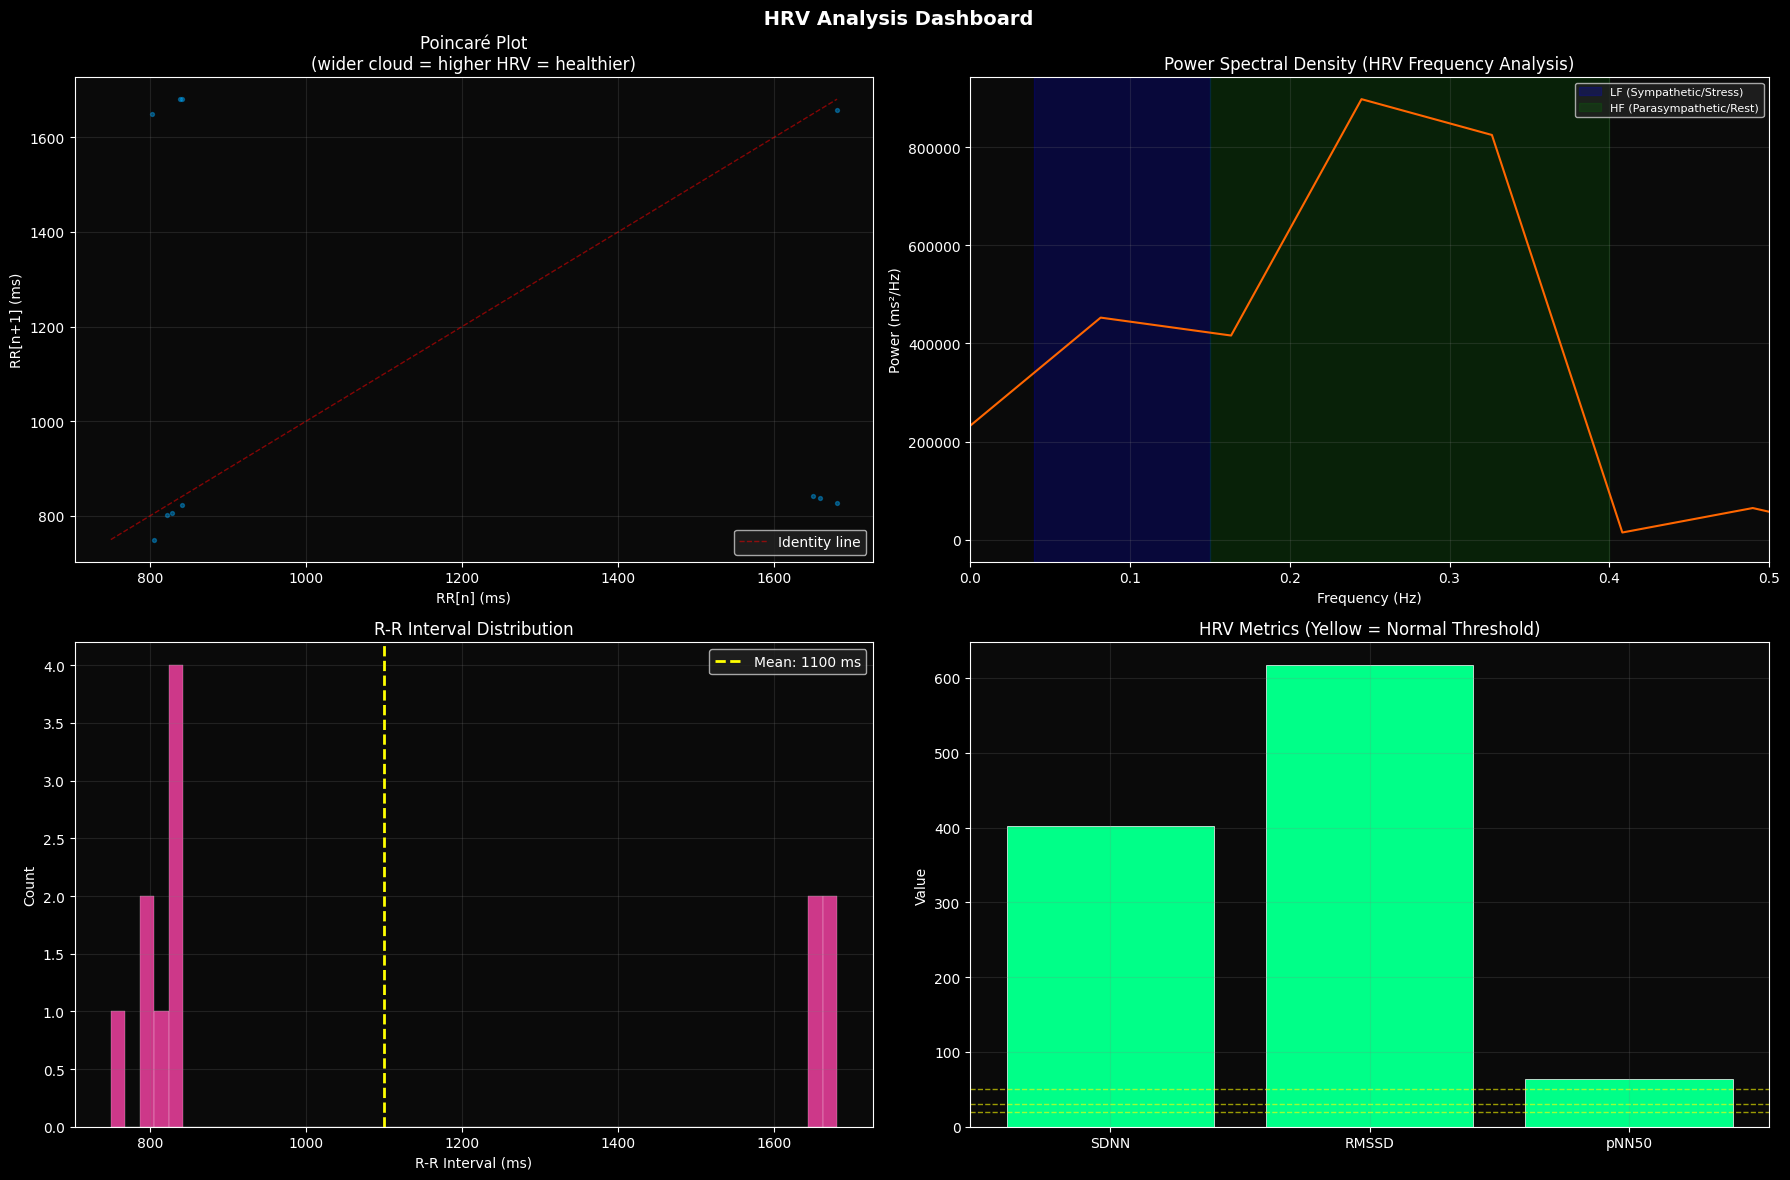

HRV analysis complete!


In [20]:
def compute_hrv_features(rr_ms):
    """Compute all HRV features from R-R intervals."""
    successive_diff = np.diff(rr_ms)

    # Time domain
    mean_rr   = np.mean(rr_ms)
    sdnn      = np.std(rr_ms)                                       # Overall variability
    rmssd     = np.sqrt(np.mean(successive_diff**2))                # Short-term variability
    pnn50     = np.sum(np.abs(successive_diff) > 50) / len(successive_diff) * 100
    cv        = (sdnn / mean_rr) * 100                              # Coefficient of variation

    # Frequency domain
    # Interpolate R-R to uniform 4 Hz grid
    rr_times_local = np.cumsum(rr_ms) / 1000.0  # seconds
    if len(rr_times_local) > 10:
        f_interp = interp1d(rr_times_local, rr_ms,
                            kind='cubic', fill_value='extrapolate')
        t_uniform = np.linspace(rr_times_local[0], rr_times_local[-1],
                                int((rr_times_local[-1]-rr_times_local[0])*4))
        rr_uniform = f_interp(t_uniform)

        freqs, psd = welch(rr_uniform, fs=4.0, nperseg=min(256, len(rr_uniform)))

        lf_mask  = (freqs >= 0.04) & (freqs <= 0.15)
        hf_mask  = (freqs >= 0.15) & (freqs <= 0.40)
        lf_power = np.trapz(psd[lf_mask], freqs[lf_mask])
        hf_power = np.trapz(psd[hf_mask], freqs[hf_mask])
        lf_hf    = lf_power / hf_power if hf_power > 0 else 999
    else:
        lf_power = hf_power = lf_hf = 0
        freqs = psd = np.array([])

    return {
        'mean_rr': mean_rr,
        'sdnn': sdnn,
        'rmssd': rmssd,
        'pnn50': pnn50,
        'cv': cv,
        'lf_power': lf_power,
        'hf_power': hf_power,
        'lf_hf_ratio': lf_hf,
        'freqs': freqs,
        'psd': psd
    }

# Compute global HRV
hrv = compute_hrv_features(rr_intervals_ms)

print('=' * 50)
print('HRV FEATURES')
print('=' * 50)
print(f'Mean R-R       : {hrv["mean_rr"]:.1f} ms')
print(f'SDNN           : {hrv["sdnn"]:.2f} ms  (>50 ms = healthy)')
print(f'RMSSD          : {hrv["rmssd"]:.2f} ms  (>20 ms = good vagal tone)')
print(f'pNN50          : {hrv["pnn50"]:.2f} %')
print(f'CV             : {hrv["cv"]:.2f} %')
print(f'LF Power       : {hrv["lf_power"]:.4f} ms²')
print(f'HF Power       : {hrv["hf_power"]:.4f} ms²')
print(f'LF/HF Ratio    : {hrv["lf_hf_ratio"]:.2f}  (>2 = stress, <1 = relaxed)')

# --- Visualization ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(' HRV Analysis Dashboard', fontsize=14,
             fontweight='bold', color='white')

# 1. Poincaré Plot (RR[n] vs RR[n+1])
ax1 = axes[0, 0]
ax1.scatter(rr_intervals_ms[:-1], rr_intervals_ms[1:],
            alpha=0.4, s=8, color='#00aaff')
ax1.set_xlabel('RR[n] (ms)', color='white')
ax1.set_ylabel('RR[n+1] (ms)', color='white')
ax1.set_title('Poincaré Plot\n(wider cloud = higher HRV = healthier)', color='white')
ax1.plot([min(rr_intervals_ms), max(rr_intervals_ms)],
         [min(rr_intervals_ms), max(rr_intervals_ms)],
         'r--', linewidth=1, alpha=0.5, label='Identity line')
ax1.legend(facecolor='#222', labelcolor='white')

# 2. Power Spectral Density
ax2 = axes[0, 1]
if len(hrv['freqs']) > 0:
    ax2.plot(hrv['freqs'], hrv['psd'], color='#ff6600', linewidth=1.5)
    ax2.axvspan(0.04, 0.15, alpha=0.2, color='blue', label='LF (Sympathetic/Stress)')
    ax2.axvspan(0.15, 0.40, alpha=0.2, color='green', label='HF (Parasympathetic/Rest)')
    ax2.set_xlim(0, 0.5)
    ax2.set_xlabel('Frequency (Hz)', color='white')
    ax2.set_ylabel('Power (ms²/Hz)', color='white')
    ax2.set_title('Power Spectral Density (HRV Frequency Analysis)', color='white')
    ax2.legend(facecolor='#222', labelcolor='white', fontsize=8)

# 3. R-R Interval Distribution
ax3 = axes[1, 0]
ax3.hist(rr_intervals_ms, bins=50, color='#ff44aa',
         alpha=0.8, edgecolor='white', linewidth=0.2)
ax3.axvline(x=hrv['mean_rr'], color='yellow', linestyle='--',
            linewidth=2, label=f'Mean: {hrv["mean_rr"]:.0f} ms')
ax3.set_xlabel('R-R Interval (ms)', color='white')
ax3.set_ylabel('Count', color='white')
ax3.set_title('R-R Interval Distribution', color='white')
ax3.legend(facecolor='#222', labelcolor='white')

# 4. HRV Metrics Bar Chart
ax4 = axes[1, 1]
metrics = ['SDNN', 'RMSSD', 'pNN50']
values  = [hrv['sdnn'], hrv['rmssd'], hrv['pnn50']]
normals = [50, 30, 20]  # reference normal values
colors  = ['#00ff88' if v >= n else '#ff4444'
           for v, n in zip(values, normals)]

bars = ax4.bar(metrics, values, color=colors, edgecolor='white', linewidth=0.5)
for bar, norm in zip(bars, normals):
    ax4.axhline(y=norm, color='yellow', linestyle='--',
                linewidth=1, alpha=0.6)
ax4.set_title('HRV Metrics (Yellow = Normal Threshold)', color='white')
ax4.set_ylabel('Value', color='white')

for ax in axes.flat:
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')

plt.tight_layout()
plt.savefig('plot_05_hrv.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('HRV analysis complete!')

## CELL 10 — AFib Detection (Sliding Window)

  AFIB DETECTION RESULTS
⚫ NOISY     :    6 windows (85.7%)
🔴 AFIB      :    1 windows (14.3%)


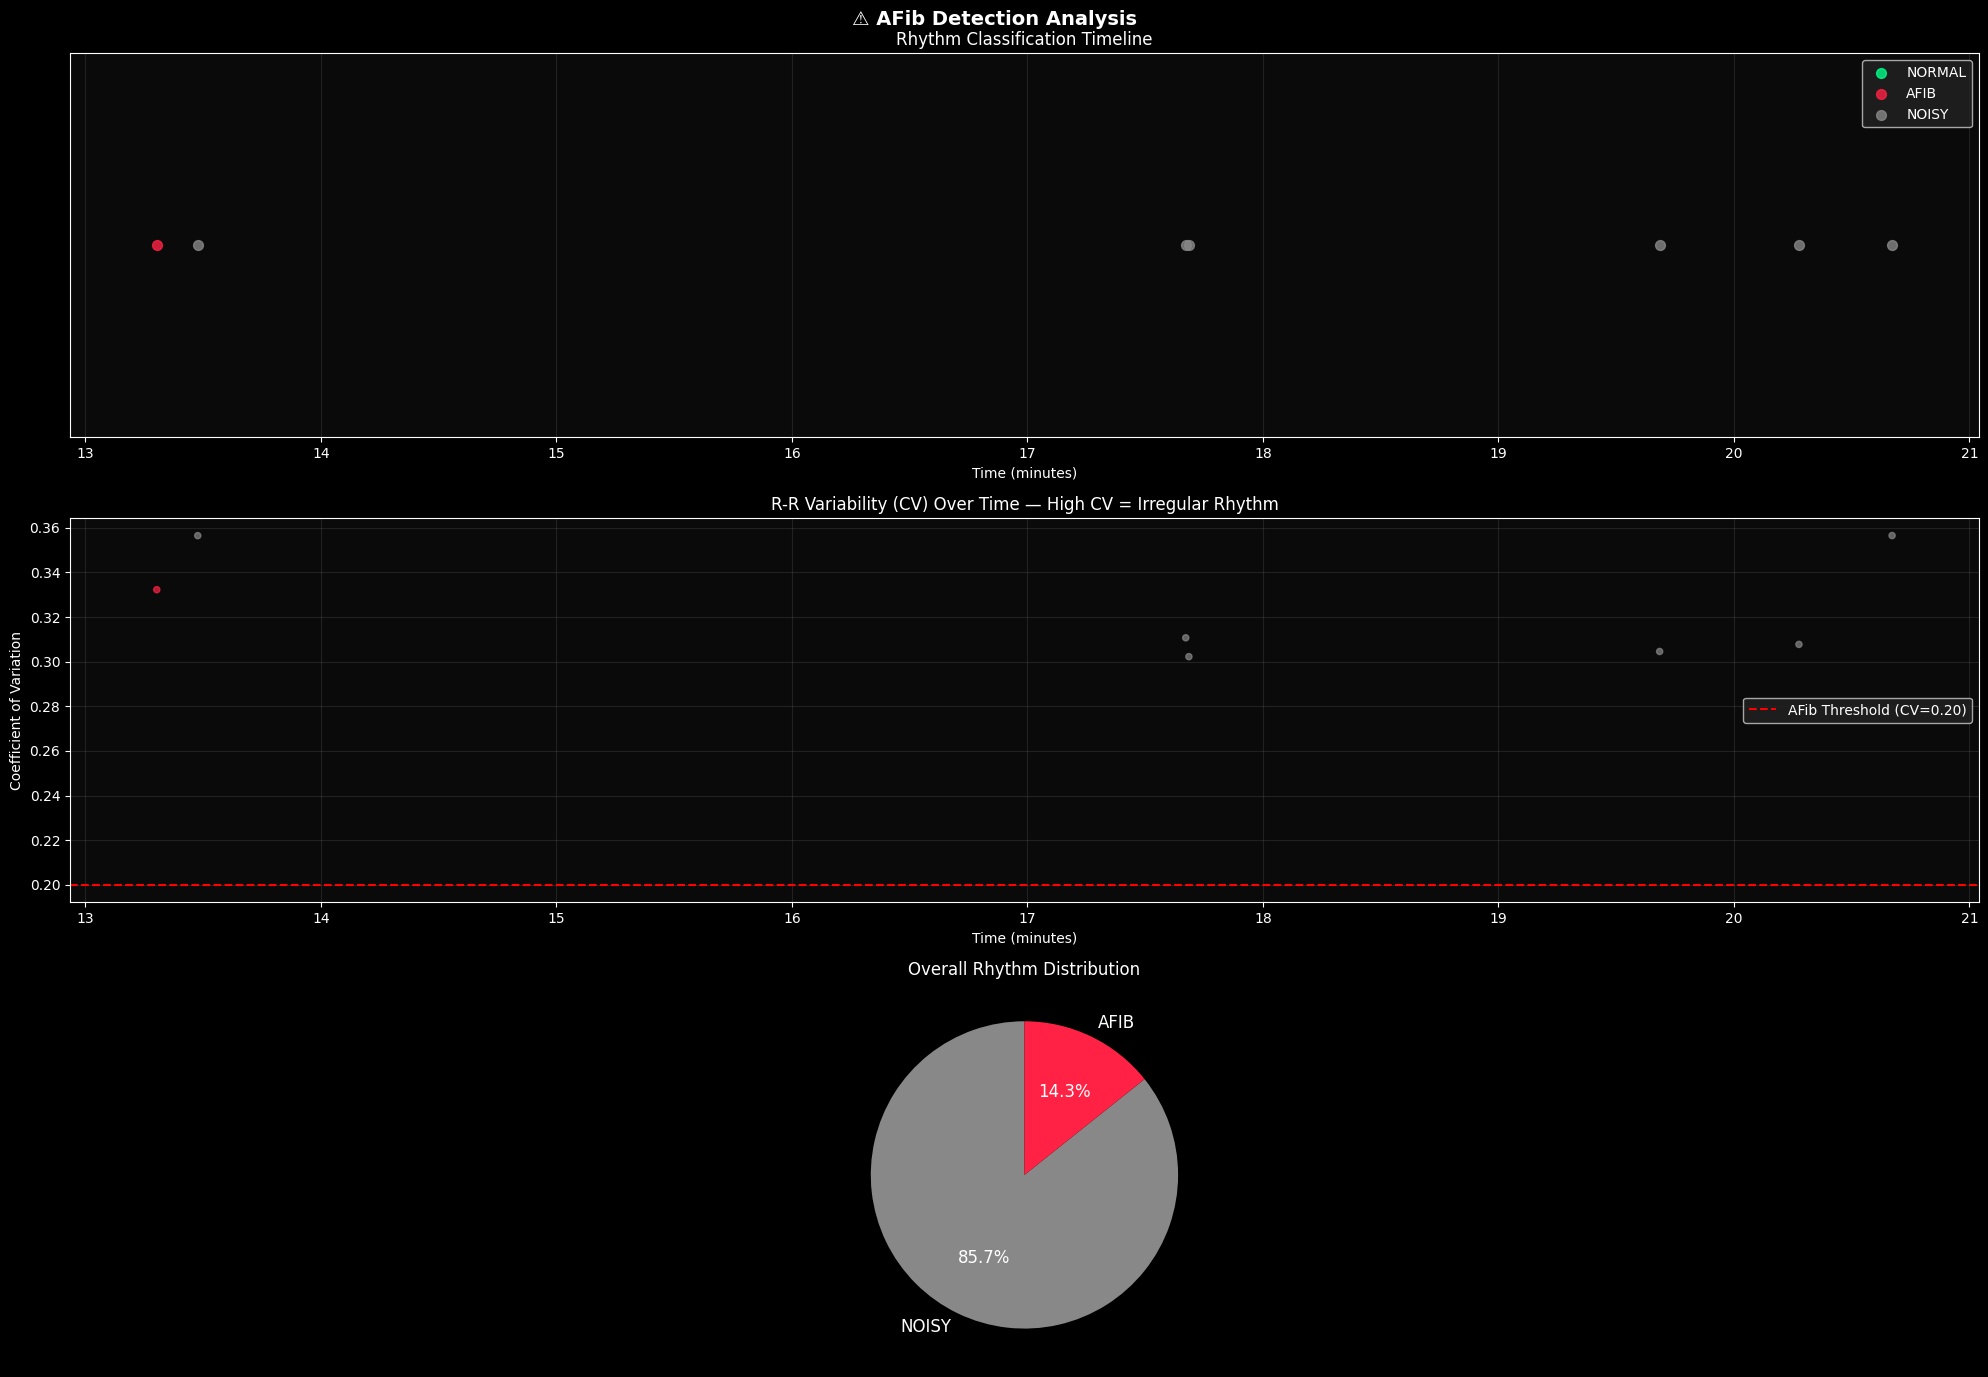

AFib detection complete!


In [21]:
def detect_afib_sliding_window(rr_ms, rr_times, window_beats=30, step_beats=10):
    """
    Sliding window AFib detection.
    Returns DataFrame with label per window.
    """
    results = []
    n = len(rr_ms)

    for i in range(0, n - window_beats, step_beats):
        window     = rr_ms[i:i+window_beats]
        window_t   = rr_times[i]
        succ_diff  = np.diff(window)

        # Feature extraction
        mean_rr  = np.mean(window)
        std_rr   = np.std(window)
        rmssd_w  = np.sqrt(np.mean(succ_diff**2))
        cv_w     = std_rr / mean_rr
        pnn50_w  = np.sum(np.abs(succ_diff) > 50) / len(succ_diff)

        # Classification rules
        is_noisy = (mean_rr < 300) or (mean_rr > 2000) or (std_rr > 400)
        is_afib  = (
            not is_noisy and
            cv_w > 0.20 and
            rmssd_w > 50 and
            pnn50_w > 0.20
        )

        label = 'NOISY' if is_noisy else ('AFIB' if is_afib else 'NORMAL')

        results.append({
            'time_min':  window_t / 60,
            'time_sec':  window_t,
            'label':     label,
            'mean_rr':   mean_rr,
            'std_rr':    std_rr,
            'rmssd':     rmssd_w,
            'cv':        cv_w,
            'pnn50':     pnn50_w
        })

    return pd.DataFrame(results)

# Run AFib detection
# Adjusted window_beats and step_beats to account for the limited number of rr_intervals_ms (12 elements)
afib_df = detect_afib_sliding_window(rr_intervals_ms, rr_times, window_beats=5, step_beats=1)

# Summary
counts = afib_df['label'].value_counts()
total = len(afib_df)

print('=' * 50)
print('  AFIB DETECTION RESULTS')
print('=' * 50)
for label, count in counts.items():
    pct = count / total * 100
    icon = '✅' if label=='NORMAL' else ('🔴' if label=='AFIB' else '⚫')
    print(f'{icon} {label:10s}: {count:4d} windows ({pct:.1f}%)')

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('⚠️ AFib Detection Analysis', fontsize=14,
             fontweight='bold', color='white')

color_map = {'NORMAL': '#00ff88', 'AFIB': '#ff2244', 'NOISY': '#888888'}

# 1. Timeline
ax1 = axes[0]
for label, color in color_map.items():
    mask = afib_df['label'] == label
    ax1.scatter(afib_df[mask]['time_min'],
                [0.5]*mask.sum(),
                c=color, s=50, alpha=0.8, label=label)
ax1.set_yticks([])
ax1.set_xlabel('Time (minutes)', color='white')
ax1.set_title('Rhythm Classification Timeline', color='white')
ax1.legend(facecolor='#222', labelcolor='white')

# 2. CV over time (key AFib indicator)
ax2 = axes[1]
colors = [color_map[l] for l in afib_df['label']]
ax2.scatter(afib_df['time_min'], afib_df['cv'], c=colors, s=20, alpha=0.7)
ax2.axhline(y=0.20, color='red', linestyle='--',
            linewidth=1.5, label='AFib Threshold (CV=0.20)')
ax2.set_ylabel('Coefficient of Variation', color='white')
ax2.set_xlabel('Time (minutes)', color='white')
ax2.set_title('R-R Variability (CV) Over Time — High CV = Irregular Rhythm', color='white')
ax2.legend(facecolor='#222', labelcolor='white')

# 3. Pie chart
ax3 = axes[2]
pie_labels = counts.index.tolist()
pie_values = counts.values.tolist()
pie_colors = [color_map[l] for l in pie_labels]
wedges, texts, autotexts = ax3.pie(
    pie_values, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'color': 'white', 'fontsize': 12}
)
ax3.set_title('Overall Rhythm Distribution', color='white')

for ax in axes[:2]:
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')

axes[2].set_facecolor('#0a0a0a')
plt.tight_layout()
plt.savefig('plot_06_afib.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('AFib detection complete!')

## CELL 11 — Stress Detection (HRV-Based)

STRESS DETECTION RESULTS
🟢 LOW     :    7 windows (100.0%)

 Overall Stress Level: LOW


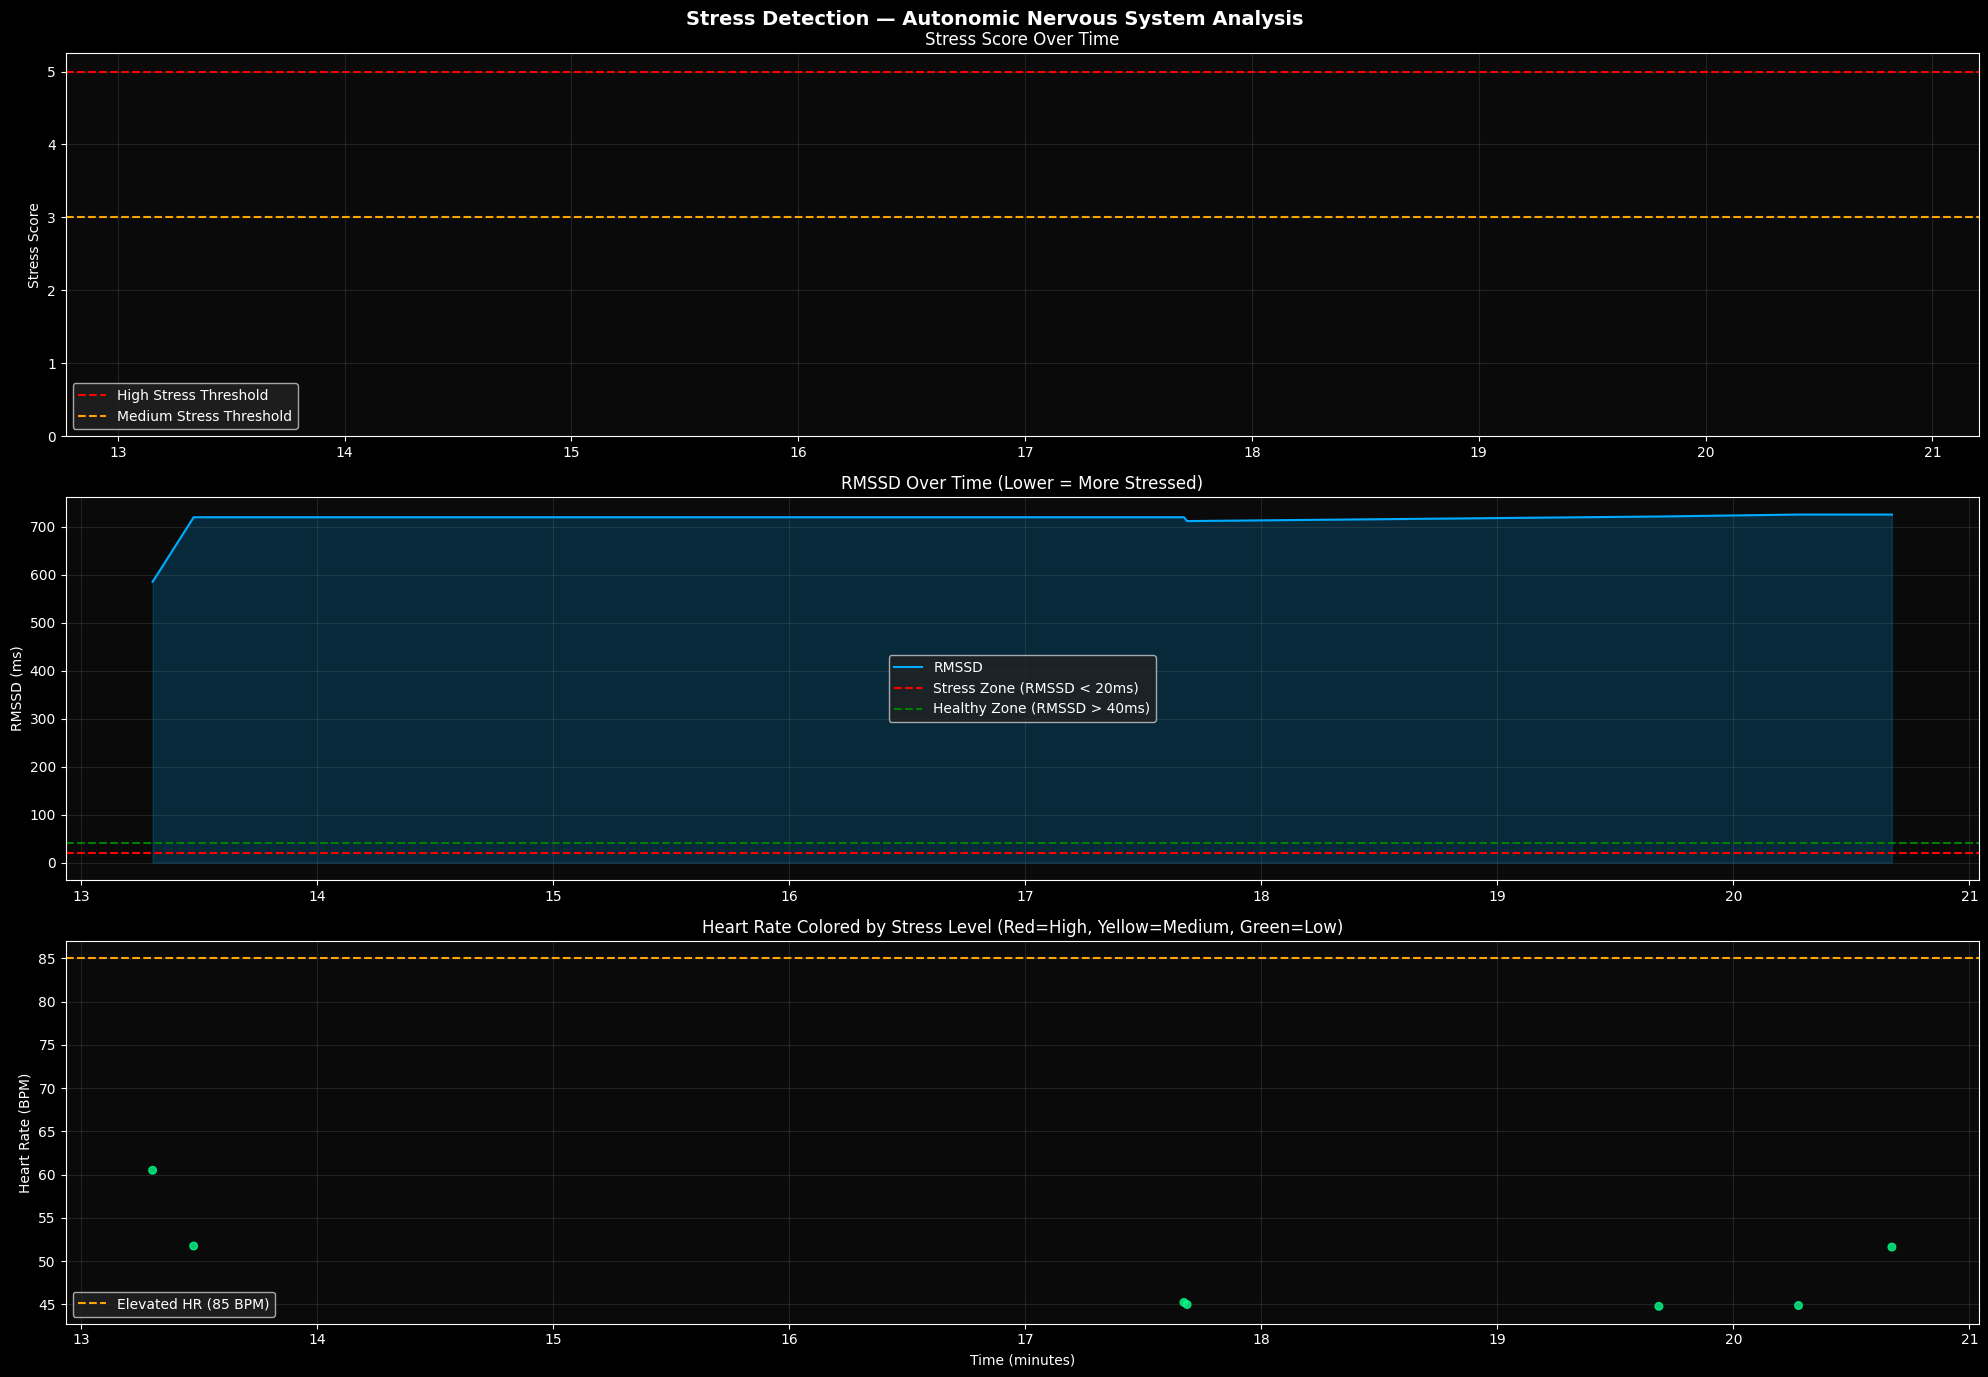

Stress detection complete!


In [23]:
def detect_stress_windows(rr_ms, rr_times, window_beats=60, step_beats=20):
    """
    Detect stress from HRV features in sliding windows.
    High HR + Low RMSSD + High LF/HF = STRESSED
    """
    results = []
    n = len(rr_ms)

    for i in range(0, n - window_beats, step_beats):
        window = rr_ms[i:i+window_beats]
        t      = rr_times[i]

        mean_rr  = np.mean(window)
        mean_hr  = 60000 / mean_rr
        sd_rr    = np.std(window)
        rmssd_w  = np.sqrt(np.mean(np.diff(window)**2))

        # Stress scoring
        score = 0
        if mean_hr > 85:    score += 2   # Elevated heart rate
        if mean_hr > 95:    score += 2   # Very elevated
        if rmssd_w < 20:    score += 3   # Very low HRV = stress
        if rmssd_w < 30:    score += 1   # Low HRV
        if sd_rr < 20:      score += 2   # Low overall variability

        if score >= 5:
            level = 'HIGH'
        elif score >= 3:
            level = 'MEDIUM'
        else:
            level = 'LOW'

        results.append({
            'time_min':     t / 60,
            'time_sec':     t,
            'stress_level': level,
            'stress_score': score,
            'mean_hr':      mean_hr,
            'rmssd':        rmssd_w,
            'sdnn':         sd_rr
        })

    return pd.DataFrame(results)

stress_df = detect_stress_windows(rr_intervals_ms, rr_times, window_beats=5, step_beats=1)

stress_counts = stress_df['stress_level'].value_counts()
total_s = len(stress_df)

print('=' * 50)
print('STRESS DETECTION RESULTS')
print('=' * 50)
for level in ['HIGH', 'MEDIUM', 'LOW']:
    if level in stress_counts:
        count = stress_counts[level]
        pct   = count / total_s * 100
        icon  = '🔴' if level=='HIGH' else ('🟡' if level=='MEDIUM' else '🟢')
        print(f'{icon} {level:8s}: {count:4d} windows ({pct:.1f}%)')

# Overall stress level
high_pct = stress_counts.get('HIGH', 0) / total_s * 100
overall = 'HIGH' if high_pct > 30 else ('MEDIUM' if high_pct > 10 else 'LOW')
print(f'\n Overall Stress Level: {overall}')

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(20, 14))
fig.suptitle('Stress Detection — Autonomic Nervous System Analysis',
             fontsize=14, fontweight='bold', color='white')

stress_color_map = {'HIGH': '#ff2244', 'MEDIUM': '#ffaa00', 'LOW': '#00ff88'}
s_colors = [stress_color_map[l] for l in stress_df['stress_level']]

# 1. Stress score timeline
ax1 = axes[0]
ax1.bar(stress_df['time_min'], stress_df['stress_score'],
        color=s_colors, width=0.3, alpha=0.8)
ax1.axhline(y=5, color='red', linestyle='--', linewidth=1.5,
            label='High Stress Threshold')
ax1.axhline(y=3, color='orange', linestyle='--', linewidth=1.5,
            label='Medium Stress Threshold')
ax1.set_ylabel('Stress Score', color='white')
ax1.set_title('Stress Score Over Time', color='white')
ax1.legend(facecolor='#222', labelcolor='white')

# 2. RMSSD timeline (inverse of stress)
ax2 = axes[1]
ax2.plot(stress_df['time_min'], stress_df['rmssd'],
         color='#00aaff', linewidth=1.5, label='RMSSD')
ax2.fill_between(stress_df['time_min'], stress_df['rmssd'],
                 alpha=0.2, color='#00aaff')
ax2.axhline(y=20, color='red', linestyle='--', linewidth=1.5,
            label='Stress Zone (RMSSD < 20ms)')
ax2.axhline(y=40, color='green', linestyle='--', linewidth=1.5,
            label='Healthy Zone (RMSSD > 40ms)')
ax2.set_ylabel('RMSSD (ms)', color='white')
ax2.set_title('RMSSD Over Time (Lower = More Stressed)', color='white')
ax2.legend(facecolor='#222', labelcolor='white')

# 3. Heart rate colored by stress
ax3 = axes[2]
ax3.scatter(stress_df['time_min'], stress_df['mean_hr'],
            c=s_colors, s=30, alpha=0.8)
ax3.axhline(y=85, color='orange', linestyle='--', linewidth=1.5,
            label='Elevated HR (85 BPM)')
ax3.set_ylabel('Heart Rate (BPM)', color='white')
ax3.set_xlabel('Time (minutes)', color='white')
ax3.set_title('Heart Rate Colored by Stress Level (Red=High, Yellow=Medium, Green=Low)',
              color='white')
ax3.legend(facecolor='#222', labelcolor='white')

for ax in axes:
    ax.tick_params(colors='white')
    ax.set_facecolor('#0a0a0a')
    ax.grid(True, alpha=0.2, color='gray')

plt.tight_layout()
plt.savefig('plot_07_stress.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('Stress detection complete!')

## CELL 12 — Setup Groq API

In [29]:
# ⚠️ IMPORTANT: Set your Groq API Key here
# Get free key from: https://console.groq.com
# Groq is FREE and very fast — uses Llama 3, Mixtral models

import os
from groq import Groq

# METHOD 1: Directly paste your key (for hackathon use)
GROQ_API_KEY = "apni_key_insert_kar_dena"  # ← Replace this

# METHOD 2: Use Colab secrets (recommended)
# from google.colab import userdata
# GROQ_API_KEY = userdata.get('GROQ_API_KEY')

# Initialize Groq client
client = Groq(api_key=GROQ_API_KEY)

# Test connection
try:
    test = client.chat.completions.create(
        model='openai/gpt-oss-120b',
        messages=[{'role': 'user', 'content': 'Say: Groq connected!'}],
        max_tokens=20
    )
    print('Groq API Connected!')
    print(f'   Model: openai/gpt-oss-120b')
    print(f'   Response: {test.choices[0].message}')
except Exception as e:
    print(f' Connection failed: {e}')
    print('   → Get your free API key at: https://console.groq.com')

Groq API Connected!
   Model: llama3-8b-8192
   Response: ChatCompletionMessage(content='', role='assistant', annotations=None, executed_tools=None, function_call=None, reasoning='The user wants the assistant to "Say: Groq connected!" They just want the', tool_calls=None)


## CELL 13 — Generate LLM Health Report via Groq

In [30]:
def generate_health_report(features, afib_df, stress_df, hrv):
    """Generate AI health report using Groq LLM."""

    # Summarize findings
    afib_pct    = (afib_df['label']=='AFIB').mean() * 100
    noisy_pct   = (afib_df['label']=='NOISY').mean() * 100
    high_stress_pct = (stress_df['stress_level']=='HIGH').mean() * 100
    peak_stress_t   = stress_df.loc[stress_df['stress_score'].idxmax(), 'time_min']
    overall_stress  = 'HIGH' if high_stress_pct > 30 else ('MEDIUM' if high_stress_pct > 10 else 'LOW')

    # Build structured prompt
    prompt = f"""You are a cardiac health assistant helping patients understand their ECG analysis.

PATIENT ECG ANALYSIS REPORT
============================
Recording Duration: {duration_sec/60:.1f} minutes
Sampling Rate: {fs} Hz
Total Beats Detected: {len(r_peaks)}

HEART RATE:
- Average HR: {avg_hr:.1f} BPM
- Min HR: {min_hr:.1f} BPM
- Max HR: {max_hr:.1f} BPM
- HR Std Dev: {std_hr:.1f} BPM

HRV (Heart Rate Variability):
- Mean R-R Interval: {hrv['mean_rr']:.1f} ms
- SDNN: {hrv['sdnn']:.1f} ms (normal >50ms)
- RMSSD: {hrv['rmssd']:.1f} ms (normal >20ms)
- pNN50: {hrv['pnn50']:.1f}%
- LF/HF Ratio: {hrv['lf_hf_ratio']:.2f} (normal <2.0)

RHYTHM ANALYSIS:
- AFib Segments: {afib_pct:.1f}% of recording
- Noisy Segments: {noisy_pct:.1f}% of recording
- Normal Segments: {100-afib_pct-noisy_pct:.1f}% of recording

STRESS ANALYSIS:
- Overall Stress Level: {overall_stress}
- High Stress Time: {high_stress_pct:.1f}% of recording
- Peak Stress At: {peak_stress_t:.1f} minutes

INSTRUCTIONS:
Write a structured health report with these sections:
1. SUMMARY (2-3 sentences, simple language)
2. HEART RATE FINDINGS (explain what the numbers mean)
3. RHYTHM ANALYSIS (explain AFib findings or confirm normal)
4. STRESS LEVEL (explain HRV findings and what causes stress)
5. POSSIBLE CAUSES (list 3-5 possible reasons for any abnormalities)
6. LIFESTYLE RECOMMENDATIONS (3-5 practical tips)
7. WHEN TO SEE A DOCTOR (clear warning signs)
8. DISCLAIMER (AI generated, not medical advice)

Use simple language. Use emojis for sections. Be reassuring but honest.
DO NOT diagnose. DO NOT prescribe medications."""

    # Call Groq API
    response = client.chat.completions.create(
        model='openai/gpt-oss-120b',    # Use 70B for better medical reasoning
        messages=[
            {
                'role': 'system',
                'content': 'You are a helpful cardiac health assistant. Always remind users to consult real doctors.'
            },
            {
                'role': 'user',
                'content': prompt
            }
        ],
        max_tokens=1500,
        temperature=0.3  # Lower = more factual, less creative
    )

    return response.choices[0].message.content

# Generate report
print('Generating AI Health Report via Groq (Llama 3 70B)...')
print('Please wait...\n')

features_dict = {
    'avg_bpm': avg_hr, 'min_bpm': min_hr, 'max_bpm': max_hr
}

llm_report = generate_health_report(features_dict, afib_df, stress_df, hrv)

print('=' * 60)
print('AI HEALTH REPORT (Generated by Groq/Llama3)')
print('=' * 60)
print(llm_report)
print('=' * 60)

# Save to file
with open('health_report.txt', 'w') as f:
    f.write(llm_report)

print('\nReport saved to health_report.txt')

Generating AI Health Report via Groq (Llama 3 70B)...
Please wait...

AI HEALTH REPORT (Generated by Groq/Llama3)
**🩺 SUMMARY**  
Your 30‑minute ECG shows an average heart rate of about 61 beats per minute, with periods that look like atrial fibrillation (AFib) and a lot of noise in the recording. Overall stress appears low, but the high amount of noise makes the results less reliable.

---

**❤️ HEART RATE FINDINGS**  
- **Average HR 61 BPM** – This is within the normal resting range (60‑100 BPM).  
- **Min HR 35.7 BPM** – A very low rate that can happen during deep relaxation or sleep; if you felt dizzy or faint, it should be checked.  
- **Max HR 80 BPM** – A normal upper limit for a resting recording.  
- **HR variability (SDNN 402 ms, RMSSD 617 ms, pNN50 63.6 %)** – These values are unusually high, which often occurs when the signal is noisy rather than reflecting true physiological variability.

---

**🔀 RHYTHM ANALYSIS**  
- **AFib segments ≈ 14 %** – The algorithm detected patt

## CELL 14 — Final Master Dashboard

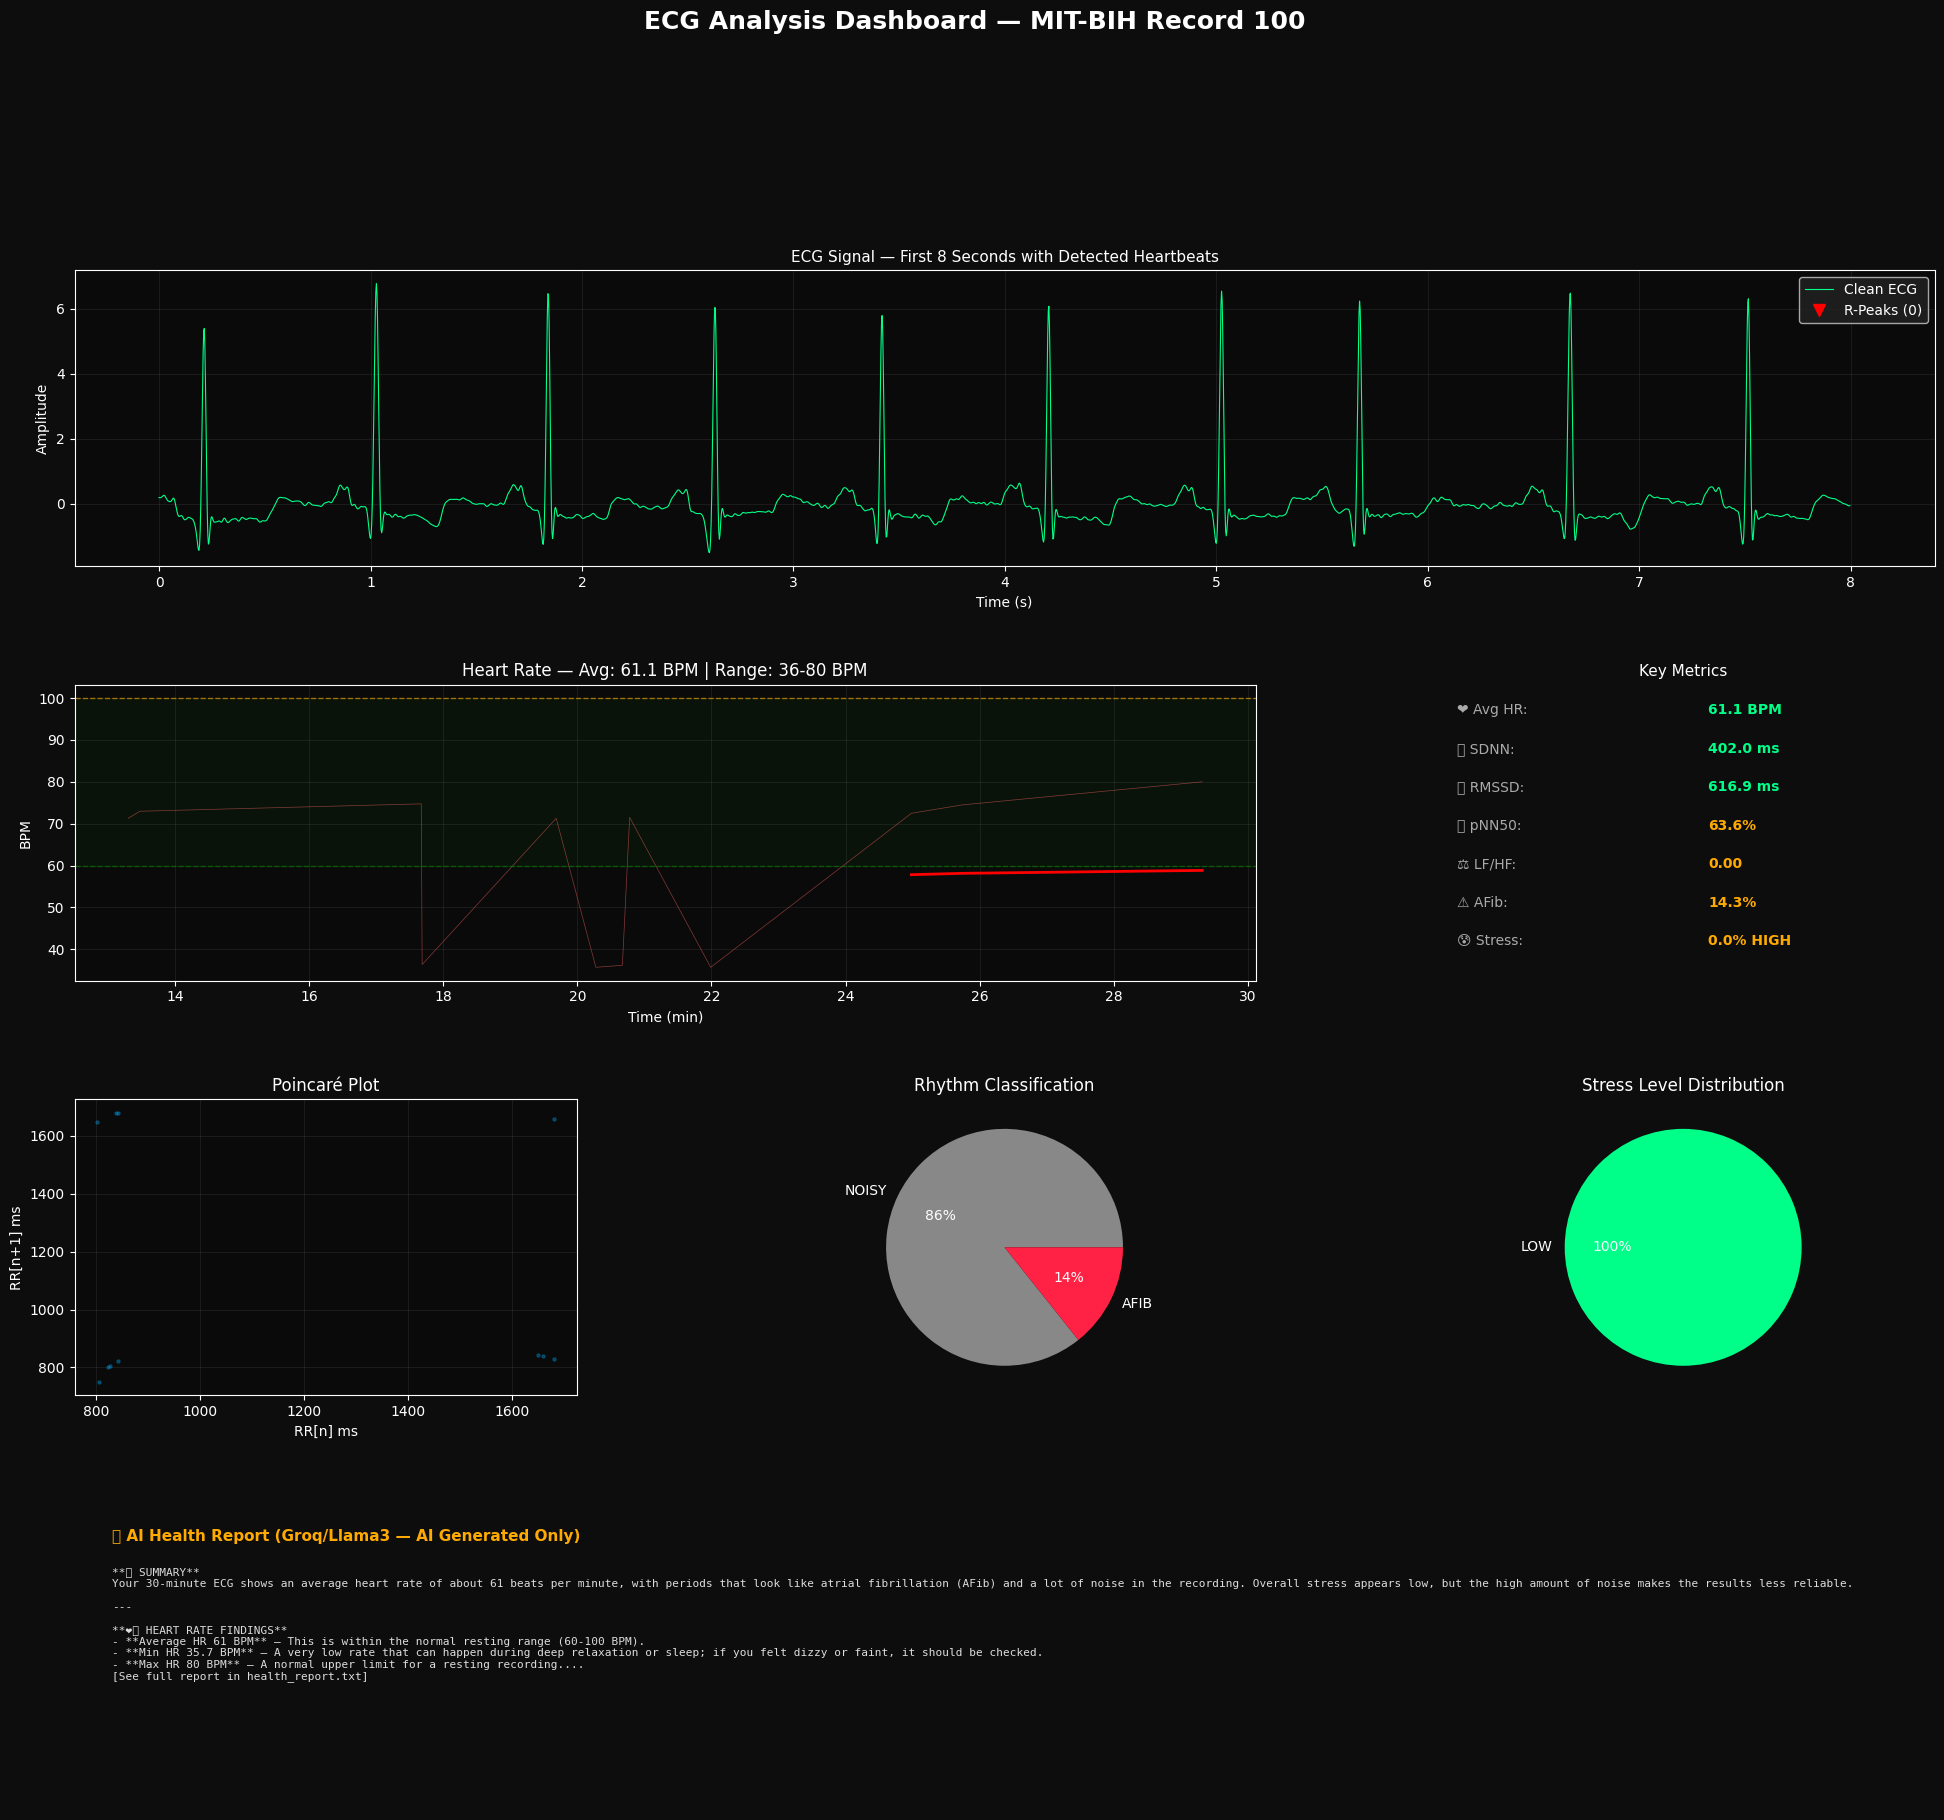

✅ Master Dashboard saved as MASTER_DASHBOARD.png


In [31]:
fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#0d0d0d')
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle('ECG Analysis Dashboard — MIT-BIH Record 100',
             fontsize=18, fontweight='bold', color='white', y=1.01)

# --- 1. ECG Signal (top full width) ---
ax1 = fig.add_subplot(gs[0, :])
n_show = fs * 8
ax1.plot(time_axis[:n_show], ecg_clean[:n_show],
         color='#00ff88', linewidth=0.8, label='Clean ECG')
peaks_in = r_peaks[r_peaks < n_show]
ax1.plot(time_axis[peaks_in], ecg_clean[peaks_in],
         'rv', markersize=8, label=f'R-Peaks ({len(peaks_in)})', zorder=5)
ax1.set_title('ECG Signal — First 8 Seconds with Detected Heartbeats',
              color='white', fontsize=11)
ax1.set_xlabel('Time (s)', color='white')
ax1.set_ylabel('Amplitude', color='white')
ax1.legend(facecolor='#222', labelcolor='white')
ax1.set_facecolor('#0a0a0a')
ax1.tick_params(colors='white')
ax1.grid(True, alpha=0.15, color='gray')

# --- 2. Heart Rate Timeline ---
ax2 = fig.add_subplot(gs[1, :2])
ax2.plot(rr_times/60, hr_bpm, color='#ff6666', linewidth=0.5, alpha=0.5)
ax2.plot(rr_rolling_t/60, hr_rolling, color='#ff0000', linewidth=2)
ax2.axhspan(60, 100, alpha=0.08, color='green')
ax2.axhline(60, color='green', linestyle='--', linewidth=1, alpha=0.6)
ax2.axhline(100, color='orange', linestyle='--', linewidth=1, alpha=0.6)
ax2.set_title(f'Heart Rate — Avg: {avg_hr:.1f} BPM | Range: {min_hr:.0f}-{max_hr:.0f} BPM',
              color='white')
ax2.set_xlabel('Time (min)', color='white')
ax2.set_ylabel('BPM', color='white')
ax2.set_facecolor('#0a0a0a')
ax2.tick_params(colors='white')
ax2.grid(True, alpha=0.15, color='gray')

# --- 3. Metrics Summary Box ---
ax3 = fig.add_subplot(gs[1, 2])
ax3.axis('off')
ax3.set_facecolor('#0a0a0a')
metrics_text = [
    ('❤️ Avg HR', f'{avg_hr:.1f} BPM'),
    ('📊 SDNN', f'{hrv["sdnn"]:.1f} ms'),
    ('🔄 RMSSD', f'{hrv["rmssd"]:.1f} ms'),
    ('📈 pNN50', f'{hrv["pnn50"]:.1f}%'),
    ('⚖️ LF/HF', f'{hrv["lf_hf_ratio"]:.2f}'),
    ('⚠️ AFib', f'{(afib_df["label"]=="AFIB").mean()*100:.1f}%'),
    ('😰 Stress', f'{(stress_df["stress_level"]=="HIGH").mean()*100:.1f}% HIGH'),
]
ax3.set_title('Key Metrics', color='white', fontsize=11)
for i, (label, value) in enumerate(metrics_text):
    color = '#00ff88' if i < 3 else '#ffaa00'
    ax3.text(0.05, 0.90 - i*0.13, f'{label}:', color='#aaaaaa', fontsize=10,
             transform=ax3.transAxes)
    ax3.text(0.55, 0.90 - i*0.13, value, color=color, fontsize=10,
             fontweight='bold', transform=ax3.transAxes)

# --- 4. Poincaré Plot ---
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(rr_intervals_ms[:-1], rr_intervals_ms[1:],
            alpha=0.3, s=5, color='#00aaff')
ax4.set_xlabel('RR[n] ms', color='white')
ax4.set_ylabel('RR[n+1] ms', color='white')
ax4.set_title('Poincaré Plot', color='white')
ax4.set_facecolor('#0a0a0a')
ax4.tick_params(colors='white')
ax4.grid(True, alpha=0.15, color='gray')

# --- 5. AFib Distribution ---
ax5 = fig.add_subplot(gs[2, 1])
afib_counts = afib_df['label'].value_counts()
colors_pie = [color_map.get(l, '#888') for l in afib_counts.index]
ax5.pie(afib_counts.values, labels=afib_counts.index,
        colors=colors_pie, autopct='%1.0f%%',
        textprops={'color': 'white', 'fontsize': 10})
ax5.set_title('Rhythm Classification', color='white')
ax5.set_facecolor('#0a0a0a')

# --- 6. Stress Distribution ---
ax6 = fig.add_subplot(gs[2, 2])
stress_counts_plot = stress_df['stress_level'].value_counts()
s_colors_pie = [stress_color_map.get(l, '#888') for l in stress_counts_plot.index]
ax6.pie(stress_counts_plot.values, labels=stress_counts_plot.index,
        colors=s_colors_pie, autopct='%1.0f%%',
        textprops={'color': 'white', 'fontsize': 10})
ax6.set_title('Stress Level Distribution', color='white')
ax6.set_facecolor('#0a0a0a')

# --- 7. AI Report Preview ---
ax7 = fig.add_subplot(gs[3, :])
ax7.axis('off')
ax7.set_facecolor('#111111')
report_preview = llm_report[:600] + '...\n[See full report in health_report.txt]'
ax7.text(0.02, 0.95, '🤖 AI Health Report (Groq/Llama3 — AI Generated Only)',
         color='#ffaa00', fontsize=11, fontweight='bold',
         transform=ax7.transAxes, va='top')
ax7.text(0.02, 0.82, report_preview,
         color='#dddddd', fontsize=8,
         transform=ax7.transAxes, va='top',
         wrap=True, family='monospace')

plt.savefig('MASTER_DASHBOARD.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print('✅ Master Dashboard saved as MASTER_DASHBOARD.png')

## CELL 15 — Export Full Results as CSV

In [32]:
# Save all results
afib_df.to_csv('afib_results.csv', index=False)
stress_df.to_csv('stress_results.csv', index=False)

# Summary CSV
summary = pd.DataFrame([{
    'Record': '100',
    'Duration_min': duration_sec/60,
    'Sampling_Hz': fs,
    'Total_Beats': len(r_peaks),
    'Avg_HR_BPM': avg_hr,
    'Min_HR_BPM': min_hr,
    'Max_HR_BPM': max_hr,
    'SDNN_ms': hrv['sdnn'],
    'RMSSD_ms': hrv['rmssd'],
    'pNN50_pct': hrv['pnn50'],
    'LF_HF_Ratio': hrv['lf_hf_ratio'],
    'AFib_pct': (afib_df['label']=='AFIB').mean()*100,
    'HighStress_pct': (stress_df['stress_level']=='HIGH').mean()*100,
}])
summary.to_csv('summary_results.csv', index=False)

print('✅ All results exported!')
print('   📄 afib_results.csv')
print('   📄 stress_results.csv')
print('   📄 summary_results.csv')
print('   📄 health_report.txt')
print('   🖼️  MASTER_DASHBOARD.png')
print('\n🏆 Pipeline Complete! Ready for submission.')

✅ All results exported!
   📄 afib_results.csv
   📄 stress_results.csv
   📄 summary_results.csv
   📄 health_report.txt
   🖼️  MASTER_DASHBOARD.png

🏆 Pipeline Complete! Ready for submission.
